# EEGSynthesizer — generación reproducible y contrato morfológico

Este notebook implementa el generador paramétrico completo. Las etiquetas
`generalized_absence` y `focal_temporal` identifican escenarios sintéticos internos;
no son diagnósticos ni modelos biofísicos completos de una crisis clínica.

## Ejecución reproducible

1. Use **Run All** en el modo predeterminado `audit_only`: verifica el dataset publicado,
   muestra resultados y topografías y no escribe datos, productos ni estado.
2. El perfil de desarrollo congelado y verificable ya forma parte del repositorio.
3. La reconstrucción completa es excepcional: exige simultáneamente
   `EEGSYNTH_MODE=full` y `EEGSYNTH_ALLOW_DATA_WRITE=1`. Si falta cualquiera, aborta
   antes de crear staging o escribir archivos.

4. `GENERATION_MODE="audit_only"` no ejecuta pilotos, no genera pacientes, no promueve
   directorios y no escribe 07, estado, topografías ni datos. El alias
   `EEGSYNTH_AUDIT_ONLY=1` fuerza ese modo y rechaza
   un `EEGSYNTH_MODE` conflictivo. Cualquier ausencia, hash inválido o desacuerdo de procedencia aborta.
5. Después ejecute una sola vez `1_1_EEGSynthesizer_VALIDATION.ipynb` en su modo predeterminado
   `siena_external`; este completa CHB-MIT y Siena, reanuda descargas y reutiliza artefactos válidos.

`CALIBRATION_MODE="frozen"` reproduce la decisión publicada y auditable. `prepare_dev` y
`recompute` se reservan para reconstruir o reevaluar la calibración con desarrollo; no son
necesarios para la reproducción normal y nunca utilizan las cohortes externas.

Principios: voltios internamente y microvoltios en persistencia; PTP operacional final
150–600 µV; lognormal truncada sin acumulación por `clip`; punta–onda frontocentral;
ritmo focal lateralizado con evolución; degradación de la señal completa; semillas por
paciente; tres pilotos; promoción atómica y separación por paciente.

Base morfológica: Seneviratne et al., *Clinical Neurophysiology* 2016,
DOI 10.1016/j.clinph.2015.08.015; Lee et al., *Epilepsia Open* 2025,
DOI 10.1002/epi4.70052. La validación es operacional y de investigación, no clínica.


In [1]:
# BLOQUE 0 — imports, rutas y configuración congelada
import atexit
import gc
import hashlib
import json
import importlib.metadata
import math
import os
import platform
import re
import shutil
import sys
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from numpy.lib.format import open_memmap
from scipy import optimize, signal, stats
from sklearn.model_selection import train_test_split

# Configuración visible para Jupyter. Las variables del sistema son opcionales.
GENERATION_MODE = "audit_only" # audit_only (predeterminado) | pilot | full autorizado
CALIBRATION_MODE = "frozen"   # frozen | recompute
REQUESTED_GENERATION_MODE = os.environ.get("EEGSYNTH_MODE")
REQUESTED_GENERATION_MODE = (REQUESTED_GENERATION_MODE.strip().lower() if REQUESTED_GENERATION_MODE is not None else None)
GENERATION_MODE = REQUESTED_GENERATION_MODE if REQUESTED_GENERATION_MODE is not None else GENERATION_MODE
AUDIT_ONLY_ENV = os.environ.get("EEGSYNTH_AUDIT_ONLY", "0").strip()
if AUDIT_ONLY_ENV not in {"0","1"}: raise ValueError("EEGSYNTH_AUDIT_ONLY debe ser 0 o 1")
if AUDIT_ONLY_ENV == "1":
    if REQUESTED_GENERATION_MODE is not None and GENERATION_MODE != "audit_only":
        raise RuntimeError("Conflicto: EEGSYNTH_AUDIT_ONLY=1 exige EEGSYNTH_MODE=audit_only o ausente")
    GENERATION_MODE = "audit_only"
CALIBRATION_MODE = os.environ.get("EEGSYNTH_CALIBRATION_MODE", CALIBRATION_MODE).strip().lower()
if GENERATION_MODE not in {"pilot","full","audit_only"}: raise ValueError("GENERATION_MODE debe ser pilot, full o audit_only")
if CALIBRATION_MODE not in {"frozen","recompute"}: raise ValueError("CALIBRATION_MODE debe ser frozen o recompute")
ALLOW_DATA_WRITE_ENV = os.environ.get("EEGSYNTH_ALLOW_DATA_WRITE", "0").strip()
if ALLOW_DATA_WRITE_ENV not in {"0","1"}: raise ValueError("EEGSYNTH_ALLOW_DATA_WRITE debe ser 0 o 1")
ALLOW_DATA_WRITE = ALLOW_DATA_WRITE_ENV == "1"
if GENERATION_MODE == "full" and not (REQUESTED_GENERATION_MODE == "full" and ALLOW_DATA_WRITE):
    raise RuntimeError("Modo full bloqueado: exige EEGSYNTH_MODE=full y EEGSYNTH_ALLOW_DATA_WRITE=1")
if GENERATION_MODE == "audit_only" and CALIBRATION_MODE != "frozen":
    raise RuntimeError("audit_only exige CALIBRATION_MODE=frozen y aborta antes de cualquier escritura")

PROJECT_ROOT = Path.cwd().resolve()
expected={"1_0_EEGSynthesizer_DATASET.ipynb","1_1_EEGSynthesizer_VALIDATION.ipynb","requirements.txt"}
missing=sorted(name for name in expected if not (PROJECT_ROOT/name).exists())
if missing: raise RuntimeError("Abra Jupyter desde la raíz del repositorio; faltan: "+", ".join(missing))

NOTEBOOK_HASH_SCOPE="code_cells_v1"
NOTEBOOK_CODE_HASH_SCHEMA="notebook-code-sha256-v1"
TRACEABILITY_MIGRATION_ID="2026-08-runall-stable-notebook-code-hash-v4"
def _normalized_code_cells(notebook_path):
    document=json.loads(Path(notebook_path).read_text(encoding="utf-8"))
    cells=[]
    for cell in document.get("cells",[]):
        if cell.get("cell_type")!="code": continue
        source=cell.get("source",[])
        source=("".join(source) if isinstance(source,list) else str(source))
        cells.append(source.replace("\r\n","\n").replace("\r","\n"))
    return cells

def notebook_code_sha256(notebook_path):
    payload={"schema":NOTEBOOK_CODE_HASH_SCHEMA,"code_cells":_normalized_code_cells(notebook_path)}
    canonical=(json.dumps(payload,separators=(",",":"),ensure_ascii=False)+"\n").encode("utf-8")
    return hashlib.sha256(canonical).hexdigest()

def notebook_stored_output_cells(notebook_path):
    document=json.loads(Path(notebook_path).read_text(encoding="utf-8"))
    return sum(bool(cell.get("outputs")) for cell in document.get("cells",[]) if cell.get("cell_type")=="code")

def assert_saved_code_matches_latest_execution(notebook_path):
    saved=[source.rstrip("\n") for source in _normalized_code_cells(notebook_path)]
    try: shell=get_ipython()
    except NameError: shell=None
    if shell is None or not getattr(shell,"history_manager",None):
        print("Comparación celdas ejecutadas/guardadas: NOT EVALUABLE fuera de IPython")
        return {"status":"NOT EVALUABLE","reason":"IPython history unavailable"}
    history=[str(source).replace("\r\n","\n").replace("\r","\n").rstrip("\n") for source in shell.history_manager.input_hist_raw[1:] if str(source).strip()]
    if len(history)<len(saved):
        raise RuntimeError(f"Solo hay {len(history)} celdas ejecutadas para {len(saved)} celdas de código guardadas; use Run All")
    observed=history[-len(saved):]
    mismatches=[idx for idx,(executed,stored) in enumerate(zip(observed,saved),1) if executed!=stored]
    if mismatches: raise RuntimeError(f"El código ejecutado no coincide con el notebook guardado en las celdas {mismatches}")
    return {"status":"SUPPORTED","code_cells":len(saved)}

def assert_saved_code_prefix_matches_latest_execution(notebook_path):
    saved=[source.rstrip("\n") for source in _normalized_code_cells(notebook_path)]
    try: shell=get_ipython()
    except NameError: shell=None
    if shell is None or not getattr(shell,"history_manager",None):
        raise RuntimeError("Una escritura autorizada exige ejecución Jupyter trazable")
    history=[str(source).replace("\r\n","\n").replace("\r","\n").rstrip("\n") for source in shell.history_manager.input_hist_raw[1:] if str(source).strip()]
    if not history: raise RuntimeError("No hay celdas ejecutadas para contrastar antes de escribir")
    matches=[index for index,source in enumerate(saved) if source==history[-1]]
    if len(matches)!=1: raise RuntimeError("La celda que intenta escribir no coincide inequívocamente con el notebook guardado")
    prefix_count=matches[0]+1
    if len(history)<prefix_count or history[-prefix_count:]!=saved[:prefix_count]:
        raise RuntimeError("El prefijo de código ejecutado no coincide con el notebook guardado; no se escribe")
    return {"status":"SUPPORTED","executed_saved_prefix_cells":prefix_count}

FINAL_DIR = PROJECT_ROOT / "dataset_eeg_final"
WORK_ROOT = PROJECT_ROOT / "tmp" / "eegsynth_rebuild"
CANDIDATE_DIR = WORK_ROOT / "dataset_eeg_candidate"
PUBLISHED_MANIFEST_PATH = FINAL_DIR / "generation_manifest.json"

PIPELINE_LOCK_PATH=PROJECT_ROOT/"tmp"/"eegsynth_pipeline.lock"
_previous_pipeline_release=globals().get("_release_eegsynth_pipeline_lock")
if callable(_previous_pipeline_release): _previous_pipeline_release()
_previous_pipeline_hook=globals().get("_eegsynth_pipeline_post_run_cell")
try:
    if _previous_pipeline_hook is not None: get_ipython().events.unregister("post_run_cell",_previous_pipeline_hook)
except (NameError,ValueError):
    pass
_PIPELINE_LOCK_OWNED=False
_PIPELINE_LOCK_TOKEN={"pid":os.getpid(),"notebook":"1_0_EEGSynthesizer_DATASET.ipynb","started_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime())}
def _release_eegsynth_pipeline_lock():
    global _PIPELINE_LOCK_OWNED
    if not _PIPELINE_LOCK_OWNED: return
    try:
        owner=json.loads(PIPELINE_LOCK_PATH.read_text(encoding="utf-8")) if PIPELINE_LOCK_PATH.is_file() else None
        if owner==_PIPELINE_LOCK_TOKEN: PIPELINE_LOCK_PATH.unlink()
    except BaseException:
        pass
    _PIPELINE_LOCK_OWNED=False
def _acquire_eegsynth_pipeline_lock():
    global _PIPELINE_LOCK_OWNED
    PIPELINE_LOCK_PATH.parent.mkdir(parents=True,exist_ok=True)
    payload=(json.dumps(_PIPELINE_LOCK_TOKEN,sort_keys=True,separators=(",",":"))+"\n").encode("utf-8")
    try:
        fd=os.open(str(PIPELINE_LOCK_PATH),os.O_WRONLY|os.O_CREAT|os.O_EXCL)
    except FileExistsError as exc:
        try: owner=PIPELINE_LOCK_PATH.read_text(encoding="utf-8").strip()
        except BaseException: owner="unreadable"
        raise RuntimeError(f"EEGSynth pipeline already running; lock={PIPELINE_LOCK_PATH}; owner={owner}") from exc
    try:
        os.write(fd,payload); os.fsync(fd)
    except BaseException:
        os.close(fd)
        try: PIPELINE_LOCK_PATH.unlink()
        except BaseException: pass
        raise
    os.close(fd); _PIPELINE_LOCK_OWNED=True
def _eegsynth_pipeline_post_run_cell(result):
    if getattr(result,"error_before_exec",None) is not None or getattr(result,"error_in_exec",None) is not None:
        _release_eegsynth_pipeline_lock()
_acquire_eegsynth_pipeline_lock()
atexit.register(_release_eegsynth_pipeline_lock)
try: get_ipython().events.register("post_run_cell",_eegsynth_pipeline_post_run_cell)
except NameError: pass
AUDIT_ONLY_MANIFEST_SHA256 = "08091538c5cb593ea711139db512145ef505b0bbc2dcface273807434a7b2db0"
AUDIT_ONLY_MANIFEST_INVENTORY = tuple(sorted((
    "cohort_metadata.csv","fig1_eeg_waveforms.pdf","fig1_eeg_waveforms.png",
    "fig2_psd_comparison.pdf","fig2_psd_comparison.png","fig3_topography.pdf",
    "fig3_topography.png","pilot_validation.csv","tabla_amplitudes.csv",
    "window_metadata_test.csv","window_metadata_train.csv","window_metadata_val.csv",
    "X_test.npy","X_train.npy","X_val.npy","y_test.npy","y_test_soft.npy",
    "y_train.npy","y_train_soft.npy","y_val.npy","y_val_soft.npy",
)))
PUBLISHED_MANIFEST_SNAPSHOT = json.loads(PUBLISHED_MANIFEST_PATH.read_text(encoding="utf-8")) if PUBLISHED_MANIFEST_PATH.exists() else None

FS = 250
DURATION = 120
N_SAMPLES = FS * DURATION
WIN_SEC = 2.0
STEP_SEC = 2.0
WIN_PTS = int(FS * WIN_SEC)
STEP_PTS = int(FS * STEP_SEC)
WINDOWS_PER_PATIENT = 1 + (N_SAMPLES - WIN_PTS) // STEP_PTS
N_PATIENTS = 3000
PILOT_SEEDS = (42, 142, 242)
PILOT_PATIENTS = 100
FINAL_SEED = 42
VAL_FRAC = 0.15
TEST_FRAC = 0.15
BIN_THR = 0.50

CH_NAMES = ["Fp1","Fp2","F7","F3","Fz","F4","F8",
            "T3","C3","Cz","C4","T4","T5","P3","Pz","P4","T6","O1","O2"]
N_CHANNELS = len(CH_NAMES)

# Contrato operacional final observable. No se presenta como rango clínico universal.
SEIZ_TARGET_MEDIAN_UV = 300.0
SEIZ_TARGET_SIGMA_LOG = 0.28
SEIZ_TARGET_MIN_UV = 150.0
SEIZ_TARGET_MAX_UV = 600.0
TARGET_REL_TOL = 0.05

BASE_AMP_MEDIAN_V = 45e-6
BASE_AMP_SIGMA_LOG = 0.40
BASE_AMP_MIN_V = 20e-6
BASE_AMP_MAX_V = 120e-6
BETA_MU, BETA_SIGMA, BETA_MIN, BETA_MAX = 2.0, 0.40, 1.2, 3.0
WHITE_NOISE_FRAC = 0.06
COMMON_FIELD_MIX = (0.18, 0.42)
TOPO_JITTER = (0.85, 1.15)
FOCAL_F0_RANGE = (6.0, 12.0)
FOCAL_F1_RANGE = (3.0, 6.0)
FOCAL_CONTRALATERAL_WEIGHT = 0.05
ALPHA_FREQ = (8.0, 12.0)
ALPHA_AMP_V = (20e-6, 50e-6)
ALPHA_PROB = 0.75
BLINK_PROB = 0.30
BLINK_AMP_V = (40e-6, 120e-6)
EMG_PROBS = (0.60, 0.30, 0.10)
DROPOUT_PROB = 0.05
CO_OCCUR_PROB = 0.15

DEV_PROFILE_DIR = PROJECT_ROOT / "dataset_doctorado_final" / "validation_q1_assets"
USE_DEV_PROFILE = os.environ.get("EEGSYNTH_USE_DEV_PROFILE", "1") == "1"
RUN_FULL = GENERATION_MODE == "full"
RUN_AUDIT_ONLY = GENERATION_MODE == "audit_only"
def require_authorized_write(operation):
    if not (RUN_FULL and REQUESTED_GENERATION_MODE=="full" and ALLOW_DATA_WRITE):
        raise RuntimeError(f"Escritura bloqueada para {operation}: exige EEGSYNTH_MODE=full y EEGSYNTH_ALLOW_DATA_WRITE=1")
    assert_saved_code_prefix_matches_latest_execution(PROJECT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb")
STATE_PATH = PROJECT_ROOT / "dataset_doctorado_final" / "reproducibility_state.json"
AUDIT_READ_ONLY_PATHS=(FINAL_DIR,PROJECT_ROOT/"figs"/"fig3_topography_es.pdf",PROJECT_ROOT/"figs"/"fig3_topography_en_us.pdf",
                       PROJECT_ROOT/"dataset_doctorado_final"/"validation_q1_assets"/"07_generalized_symmetry_by_patient.csv",
                       PROJECT_ROOT/"dataset_doctorado_final"/"validation_q1_assets"/"07_generalized_symmetry_summary.json",STATE_PATH)
def read_only_artifact_snapshot(paths):
    snapshot={}
    for item in map(Path,paths):
        members=sorted((p for p in item.rglob("*") if p.is_file()),key=lambda p:p.as_posix()) if item.is_dir() else ([item] if item.exists() else [])
        snapshot[str(item.resolve())]=[(str(path.resolve()),path.stat().st_size,path.stat().st_mtime_ns) for path in members]
    return snapshot
AUDIT_READ_ONLY_SNAPSHOT=read_only_artifact_snapshot(AUDIT_READ_ONLY_PATHS) if RUN_AUDIT_ONLY else None
CONFIG = {
    "schema_version": "4.0",
    "fs_hz": FS, "duration_s": DURATION, "window_s": WIN_SEC, "step_s": STEP_SEC,
    "n_patients": N_PATIENTS, "final_seed": FINAL_SEED,
    "class_counts": {"none": 1500, "generalized_absence": 750, "focal_temporal": 750},
    "target_ptp_uv": {"distribution": "truncated_lognormal", "median": SEIZ_TARGET_MEDIAN_UV,
                      "sigma_log": SEIZ_TARGET_SIGMA_LOG, "min": SEIZ_TARGET_MIN_UV,
                      "max": SEIZ_TARGET_MAX_UV, "relative_tolerance": TARGET_REL_TOL},
    "scenario_semantics": "internal_parametric_not_clinical_diagnoses",
    "degradation_order": "after_complete_composition",
    "pilot_seeds": list(PILOT_SEEDS), "pilot_patients_per_seed": PILOT_PATIENTS,
}
CONFIG["generation_mode"]=GENERATION_MODE
CONFIG["calibration_mode"]=CALIBRATION_MODE
CONFIG["notebook_code_sha256"]=notebook_code_sha256(PROJECT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb")
versions={name:importlib.metadata.version(name) for name in ("numpy","pandas","scipy","scikit-learn")}
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))
print("Entorno:",sys.version.split()[0],versions)
print(f"Espacio libre: {shutil.disk_usage(PROJECT_ROOT).free/(1024**3):.2f} GiB")
print("Trazabilidad de código:",CONFIG["notebook_code_sha256"],"; celdas con outputs guardados:",notebook_stored_output_cells(PROJECT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb"))


{
  "schema_version": "4.0",
  "fs_hz": 250,
  "duration_s": 120,
  "window_s": 2.0,
  "step_s": 2.0,
  "n_patients": 3000,
  "final_seed": 42,
  "class_counts": {
    "none": 1500,
    "generalized_absence": 750,
    "focal_temporal": 750
  },
  "target_ptp_uv": {
    "distribution": "truncated_lognormal",
    "median": 300.0,
    "sigma_log": 0.28,
    "min": 150.0,
    "max": 600.0,
    "relative_tolerance": 0.05
  },
  "scenario_semantics": "internal_parametric_not_clinical_diagnoses",
  "degradation_order": "after_complete_composition",
  "pilot_seeds": [
    42,
    142,
    242
  ],
  "pilot_patients_per_seed": 100,
  "generation_mode": "audit_only",
  "calibration_mode": "frozen",
  "notebook_code_sha256": "2a921f5b891826ac2d1d61ebfdecd5ad22edd5c0cfb0f447feefb3d3e9a94099"
}
Entorno: 3.13.7 {'numpy': '2.4.2', 'pandas': '3.0.1', 'scipy': '1.17.1', 'scikit-learn': '1.8.0'}
Espacio libre: 350.85 GiB
Trazabilidad de código: 2a921f5b891826ac2d1d61ebfdecd5ad22edd5c0cfb0f447feefb3d3e9a

In [2]:
# BLOQUE 1 — utilidades numéricas y morfologías
def stable_seed(root_seed, patient_id, attempt=0):
    return int(np.random.SeedSequence([int(root_seed), int(patient_id), int(attempt)]).generate_state(1)[0])


def truncated_lognormal_uv(rng):
    mu = math.log(SEIZ_TARGET_MEDIAN_UV)
    lo = (math.log(SEIZ_TARGET_MIN_UV) - mu) / SEIZ_TARGET_SIGMA_LOG
    hi = (math.log(SEIZ_TARGET_MAX_UV) - mu) / SEIZ_TARGET_SIGMA_LOG
    u = rng.uniform(stats.norm.cdf(lo), stats.norm.cdf(hi))
    return float(math.exp(mu + SEIZ_TARGET_SIGMA_LOG * stats.norm.ppf(u)))


def clipped_lognormal(rng, median, sigma, low, high):
    return float(np.clip(rng.lognormal(math.log(median), sigma), low, high))


def colored_noise(rng, n_channels, n_samples, beta):
    u = rng.normal(size=(n_channels, n_samples))
    spec = np.fft.rfft(u, axis=1)
    freqs = np.fft.rfftfreq(n_samples)
    scale = np.ones_like(freqs)
    scale[1:] = freqs[1:] ** (-beta / 2.0)
    x = np.fft.irfft(spec * scale[None, :], n=n_samples, axis=1)
    x -= x.mean(axis=1, keepdims=True)
    x /= x.std(axis=1, keepdims=True) + 1e-12
    return x


def smooth_gate(n, fs, ramp_s=0.75):
    gate = np.ones(n, dtype=np.float64)
    r = min(int(round(ramp_s * fs)), n // 2)
    if r > 1:
        edge = np.sin(np.linspace(0, np.pi / 2, r)) ** 2
        gate[:r] = edge
        gate[-r:] = edge[::-1]
    return gate


def cyclic_distance(phase01, center):
    return ((phase01 - center + 0.5) % 1.0) - 0.5


def generalized_spike_wave(rng, n, fs):
    freq = float(rng.uniform(2.5, 4.0))
    phase0 = float(rng.uniform(0, 2 * np.pi))
    phase = phase0 + 2 * np.pi * freq * np.arange(n) / fs
    p = (phase / (2 * np.pi)) % 1.0
    spike = np.exp(-0.5 * (cyclic_distance(p, 0.08) / 0.030) ** 2)
    slow = -0.72 * np.exp(-0.5 * (cyclic_distance(p, 0.37) / 0.145) ** 2)
    wave = (spike + slow) * smooth_gate(n, fs, 0.6)
    sos = signal.butter(4, 6.0, btype="lowpass", fs=fs, output="sos")
    wave = signal.sosfiltfilt(sos, wave)
    wave -= wave.mean()
    wave /= np.ptp(wave) + 1e-12
    return wave, {"freq_start_hz": freq, "freq_end_hz": freq, "freq_slope_hz_s": 0.0}


def focal_evolving_rhythm(rng, n, fs):
    # Patrón operacional inspirado en la evolución descrita para crisis focales:
    # inicio más rápido y de menor amplitud, seguido de enlentecimiento y aumento.
    f0 = float(rng.uniform(*FOCAL_F0_RANGE))
    upper_f1 = min(FOCAL_F1_RANGE[1], f0 - 0.75)
    f1 = float(rng.uniform(FOCAL_F1_RANGE[0], max(FOCAL_F1_RANGE[0] + 1e-6, upper_f1)))
    t = np.arange(n) / fs
    progress = np.linspace(0.0, 1.0, n)
    freq = f0 + (f1 - f0) * (3 * progress**2 - 2 * progress**3)
    phase = float(rng.uniform(0, 2*np.pi)) + 2*np.pi*np.cumsum(freq) / fs
    carrier = np.sin(phase) + 0.24*np.sin(2*phase + rng.uniform(-0.5, 0.5))
    envelope = (0.32 + 0.68 * (3*progress**2 - 2*progress**3)) * smooth_gate(n, fs, 0.8)
    wave = carrier * envelope
    # Transitorios agudos escasos, siempre ligados a la fase, no tren idéntico punta–onda.
    for k in range(1, max(2, int(n / fs / 4))):
        center = int((k * n / max(2, int(n / fs / 4))) + rng.integers(-fs//5, fs//5))
        if 4 <= center < n-5 and rng.random() < 0.55:
            width = int(rng.integers(max(3, fs//80), max(4, fs//35)))
            a, b = max(0, center-3*width), min(n, center+3*width+1)
            q = np.arange(a, b) - center
            wave[a:b] += rng.uniform(0.10, 0.24) * np.exp(-0.5*(q/width)**2)
    sos = signal.butter(4, [1.0, 20.0], btype="bandpass", fs=fs, output="sos")
    wave = signal.sosfiltfilt(sos, wave)
    wave -= wave.mean()
    wave /= np.ptp(wave) + 1e-12
    return wave, {"freq_start_hz": f0, "freq_end_hz": f1,
                  "freq_slope_hz_s": (f1-f0) / max(n/fs, 1e-9)}


GENERALIZED_WEIGHTS = {
    "Fp1":1.10,"Fp2":1.10,"F7":0.60,"F3":1.00,"Fz":1.10,"F4":1.00,"F8":0.60,
    "T3":0.30,"C3":0.40,"Cz":0.50,"C4":0.40,"T4":0.30,"T5":0.10,"P3":0.10,
    "Pz":0.20,"P4":0.10,"T6":0.10,"O1":0.05,"O2":0.05,
}
FOCAL_LEFT_WEIGHTS = {"T3":1.20,"F7":0.80,"T5":0.80,"C3":0.50,"Fp1":0.40,"F3":0.40,"P3":0.30,"O1":0.10}
FOCAL_RIGHT_WEIGHTS = {"T4":1.20,"F8":0.80,"T6":0.80,"C4":0.50,"Fp2":0.40,"F4":0.40,"P4":0.30,"O2":0.10}
PRIMARY_GENERALIZED = ["Fp1","Fp2","F3","Fz","F4"]
PRIMARY_FOCAL_LEFT = ["T3","F7","T5","C3"]
PRIMARY_FOCAL_RIGHT = ["T4","F8","T6","C4"]


MEASURE_SOS = signal.butter(4, [1.0, 30.0], btype="bandpass", fs=FS, output="sos")


def filtered_ptp_uv(segment_v, channel_indices):
    if segment_v.shape[1] < 3 * 12:
        return float("nan")
    xf = signal.sosfiltfilt(MEASURE_SOS, segment_v[channel_indices], axis=1)
    return float(np.median(np.ptp(xf, axis=1)) * 1e6)


def dominant_frequency(x, fs, fmin=1.0, fmax=20.0):
    f, p = signal.welch(np.asarray(x, dtype=np.float64), fs=fs,
                        nperseg=min(len(x), 2*fs))
    mask = (f >= fmin) & (f <= fmax)
    return float(f[mask][np.argmax(p[mask])]) if np.any(mask) else float("nan")


In [3]:
# BLOQUE 2 — sintetizador completo y calibración del PTP final
class EEGSynthesizer:
    def __init__(self, fs=FS, duration=DURATION):
        self.fs = fs
        self.duration = duration
        self.n_samples = int(fs * duration)

    def _background(self, rng):
        beta = float(np.clip(rng.normal(BETA_MU, BETA_SIGMA), BETA_MIN, BETA_MAX))
        amp = clipped_lognormal(rng, BASE_AMP_MEDIAN_V, BASE_AMP_SIGMA_LOG,
                                BASE_AMP_MIN_V, BASE_AMP_MAX_V)
        independent = colored_noise(rng, N_CHANNELS, self.n_samples, beta)
        common = colored_noise(rng, 1, self.n_samples, beta)[0]
        mix = float(rng.uniform(*COMMON_FIELD_MIX))
        x = (math.sqrt(1-mix) * independent + math.sqrt(mix) * common[None, :]) * amp
        x += rng.normal(0, amp * WHITE_NOISE_FRAC, size=x.shape)
        # Ritmo alfa posterior con variación leve por paciente.
        alpha_f = float(rng.uniform(*ALPHA_FREQ))
        alpha_a = float(rng.uniform(*ALPHA_AMP_V))
        phase = float(rng.uniform(0, 2*np.pi))
        alpha = np.sin(2*np.pi*alpha_f*np.arange(self.n_samples)/self.fs + phase) * alpha_a
        alpha_weights = {"O1":1.0,"O2":1.0,"P3":0.55,"Pz":0.60,"P4":0.55,"T5":0.25,"T6":0.25}
        for ci, ch in enumerate(CH_NAMES):
            if ch in alpha_weights and rng.random() < ALPHA_PROB:
                x[ci] += alpha * alpha_weights[ch] * rng.uniform(0.85,1.15)
        return x, beta, amp, alpha_f

    def _add_blink(self, rng, x, artifact_mask, center=None):
        length = int(rng.uniform(0.35, 0.9) * self.fs)
        if center is None:
            start = int(rng.integers(0, max(1, self.n_samples-length)))
        else:
            start = int(np.clip(center - length//2, 0, self.n_samples-length))
        q = np.linspace(-2.8, 2.8, length)
        pulse = np.exp(-0.5*q*q) * rng.uniform(*BLINK_AMP_V)
        for ch, w in {"Fp1":1.0,"Fp2":1.0,"F7":0.30,"F3":0.35,"F4":0.35,"F8":0.30}.items():
            x[CH_NAMES.index(ch), start:start+length] += pulse * w * rng.uniform(0.85,1.15)
        artifact_mask[start:start+length] = True

    def _add_emg(self, rng, x, artifact_mask, start=None, end=None, strength=1.0):
        if start is None:
            length = int(rng.uniform(0.4, 2.0) * self.fs)
            start = int(rng.integers(0, max(1, self.n_samples-length)))
            end = start + length
        length = int(end-start)
        if length < 10:
            return
        sos = signal.butter(4, [25, 90], btype="bandpass", fs=self.fs, output="sos")
        channels = rng.choice(N_CHANNELS, size=int(rng.integers(2, 7)), replace=False)
        for ci in channels:
            noise = signal.sosfiltfilt(sos, rng.normal(size=length))
            noise /= np.std(noise) + 1e-12
            x[ci, start:end] += noise * rng.uniform(8e-6, 28e-6) * strength
        artifact_mask[start:end] = True

    def _confuser(self, rng, x):
        if rng.random() >= 0.50:
            return False
        dur = float(rng.uniform(1.0, 3.0)); n = int(dur*self.fs)
        start = int(rng.integers(0, self.n_samples-n))
        f = float(rng.uniform(4.0, 8.0)); amp = float(rng.uniform(40e-6, 120e-6))
        wave = np.sin(2*np.pi*f*np.arange(n)/self.fs + rng.uniform(0,2*np.pi))*smooth_gate(n,self.fs,0.25)*amp
        channels = rng.choice(N_CHANNELS, size=int(rng.integers(2,6)), replace=False)
        for ci in channels: x[ci,start:start+n] += wave*rng.uniform(0.4,1.0)
        return True

    def _event_component(self, rng, scenario, start, duration):
        i0 = int(round(start*self.fs)); n = int(round(duration*self.fs)); i1 = min(self.n_samples, i0+n)
        n = i1-i0
        unit = np.zeros((N_CHANNELS, self.n_samples), dtype=np.float64)
        if scenario == "generalized_absence":
            wave, evo = generalized_spike_wave(rng, n, self.fs)
            weights = GENERALIZED_WEIGHTS
            lateral = "bilateral"
            primary = PRIMARY_GENERALIZED
            default_weight = 0.05
        elif scenario == "focal_temporal":
            wave, evo = focal_evolving_rhythm(rng, n, self.fs)
            lateral = "left" if rng.random() < 0.5 else "right"
            weights = FOCAL_LEFT_WEIGHTS if lateral == "left" else FOCAL_RIGHT_WEIGHTS
            default_weight = FOCAL_CONTRALATERAL_WEIGHT
            primary = PRIMARY_FOCAL_LEFT if lateral == "left" else PRIMARY_FOCAL_RIGHT
        else:
            raise ValueError(scenario)
        actual_weights = []
        for ci, ch in enumerate(CH_NAMES):
            w = float(weights.get(ch, default_weight) * rng.uniform(*TOPO_JITTER))
            unit[ci, i0:i1] = wave * w
            actual_weights.append(w)
        return unit, i0, i1, lateral, primary, actual_weights, evo

    def _measurement_slice(self, i0, i1, artifact_mask):
        margin = int(0.20 * (i1-i0))
        lo, hi = i0+margin, i1-margin
        win = min(WIN_PTS, max(0, hi-lo))
        if win < WIN_PTS:
            return slice(max(i0, (i0+i1-WIN_PTS)//2), min(i1, (i0+i1+WIN_PTS)//2)), False
        candidates = np.arange(lo, hi-WIN_PTS+1, max(1, WIN_PTS//4))
        clean = [int(s) for s in candidates if not artifact_mask[s:s+WIN_PTS].any()]
        if clean:
            s = clean[len(clean)//2]
            return slice(s, s+WIN_PTS), True
        s = int(candidates[len(candidates)//2])
        return slice(s, s+WIN_PTS), False

    def generate_patient(self, scenario, root_seed, patient_id, max_attempts=10):
        for attempt in range(1, max_attempts+1):
            patient_seed = stable_seed(root_seed, patient_id, attempt-1)
            rng = np.random.default_rng(patient_seed)
            base, beta, base_amp, alpha_f = self._background(rng)
            artifact_mask = np.zeros(self.n_samples, dtype=bool)
            blink = rng.random() < BLINK_PROB
            if blink: self._add_blink(rng, base, artifact_mask)
            emg_level = int(rng.choice([0,1,2], p=EMG_PROBS))
            for _ in range(emg_level): self._add_emg(rng, base, artifact_mask)

            labels = np.zeros(self.n_samples, dtype=np.float32)
            unit = np.zeros_like(base)
            target_uv = observed_uv = rel_error = float("nan")
            start = duration = 0.0; lateral = "none"; primary = []
            weights = [0.0]*N_CHANNELS
            evo = {"freq_start_hz":float("nan"),"freq_end_hz":float("nan"),"freq_slope_hz_s":float("nan")}
            confuser = False; co_artifact = False; measure_clean = True

            if scenario == "none":
                confuser = self._confuser(rng, base)
                i0 = i1 = 0
            else:
                if scenario == "generalized_absence":
                    duration = float(np.clip(rng.lognormal(math.log(8.0),0.45), 3.0, 30.0))
                else:
                    duration = float(np.clip(rng.lognormal(math.log(25.0),0.50), 8.0, 75.0))
                start = float(rng.uniform(5.0, max(5.01, DURATION-duration-5.0)))
                unit, i0, i1, lateral, primary, weights, evo = self._event_component(rng,scenario,start,duration)
                labels[i0:i1] = 1.0
                if rng.random() < CO_OCCUR_PROB:
                    co_artifact = True
                    center = int(rng.integers(i0, max(i0+1,i1)))
                    if rng.random() < 0.5: self._add_blink(rng,base,artifact_mask,center=center)
                    else:
                        n = int(rng.uniform(0.4,1.5)*self.fs)
                        self._add_emg(rng,base,artifact_mask,max(i0,center-n//2),min(i1,center+n//2),1.2)

            degradation = np.ones(N_CHANNELS, dtype=np.float64)
            degraded = []
            for ci,ch in enumerate(CH_NAMES):
                if rng.random() < DROPOUT_PROB:
                    degradation[ci] = rng.uniform(0.05,0.15)
                    degraded.append(ch)
            base_d = base * degradation[:,None]
            unit_d = unit * degradation[:,None]

            amplitude_ok = True
            morphology_ok = True
            gen_freq_ok = focal_evolution_ok = laterality_ok = symmetry_ok = True
            scale_v = 0.0
            if scenario != "none":
                target_uv = truncated_lognormal_uv(rng)
                mslice, measure_clean = self._measurement_slice(i0,i1,artifact_mask)
                primary_idx = [CH_NAMES.index(c) for c in primary if c not in degraded]
                if not primary_idx:
                    primary_idx = [CH_NAMES.index(c) for c in primary]
                bf = signal.sosfiltfilt(MEASURE_SOS, base_d[primary_idx,mslice], axis=1)
                uf = signal.sosfiltfilt(MEASURE_SOS, unit_d[primary_idx,mslice], axis=1)
                unit_ptp = float(np.median(np.ptp(uf,axis=1))*1e6)
                guess = target_uv / max(unit_ptp,1e-9)
                upper = max(guess*3.0, 5e-4)
                def objective(a):
                    val = float(np.median(np.ptp(bf+a*uf,axis=1))*1e6)
                    return abs(val-target_uv)
                opt = optimize.minimize_scalar(objective,bounds=(0.0,upper),method="bounded",
                                               options={"xatol":1e-8,"maxiter":60})
                scale_v = float(opt.x)
                observed_uv = filtered_ptp_uv(base_d[:,mslice]+scale_v*unit_d[:,mslice], primary_idx)
                rel_error = abs(observed_uv-target_uv)/target_uv
                amplitude_ok = bool(np.isfinite(observed_uv) and SEIZ_TARGET_MIN_UV <= observed_uv <= SEIZ_TARGET_MAX_UV and rel_error <= TARGET_REL_TOL)

                seg = base_d[:,i0:i1] + scale_v*unit_d[:,i0:i1]
                if scenario == "generalized_absence":
                    fz = signal.sosfiltfilt(MEASURE_SOS, seg[CH_NAMES.index("Fz")])
                    freq_obs = dominant_frequency(fz,self.fs,2.0,8.0)
                    gen_freq_ok = 2.5 <= freq_obs <= 4.0
                    pairs=[]
                    for l,r in [("Fp1","Fp2"),("F3","F4")]:
                        if l not in degraded and r not in degraded:
                            pl=np.ptp(signal.sosfiltfilt(MEASURE_SOS,seg[CH_NAMES.index(l)]))
                            pr=np.ptp(signal.sosfiltfilt(MEASURE_SOS,seg[CH_NAMES.index(r)]))
                            pairs.append(abs(pl-pr)/(max(pl,pr)+1e-12))
                    symmetry_ok = bool(not pairs or np.median(pairs) <= 0.35)
                else:
                    nseg=seg.shape[1]; third=max(WIN_PTS,nseg//3)
                    dom_ch = primary[0]; x=signal.sosfiltfilt(MEASURE_SOS,seg[CH_NAMES.index(dom_ch)])
                    f_first=dominant_frequency(x[:third],self.fs,1.0,20.0)
                    f_last=dominant_frequency(x[-third:],self.fs,1.0,20.0)
                    rms_first=float(np.sqrt(np.mean(x[:third]**2))); rms_last=float(np.sqrt(np.mean(x[-third:]**2)))
                    focal_evolution_ok = bool(f_first > f_last and rms_last > rms_first)
                    left=np.median([np.ptp(seg[CH_NAMES.index(c)]) for c in PRIMARY_FOCAL_LEFT])
                    right=np.median([np.ptp(seg[CH_NAMES.index(c)]) for c in PRIMARY_FOCAL_RIGHT])
                    laterality_ok = bool((lateral=="left" and left>1.15*right) or (lateral=="right" and right>1.15*left))
                morphology_ok = bool(gen_freq_ok and focal_evolution_ok and laterality_ok and symmetry_ok)

            data_v = base_d + scale_v * unit_d
            if scenario == "none" or (amplitude_ok and morphology_ok):
                meta = {
                    "patient_id":int(patient_id),"patient_seed":patient_seed,"attempts":attempt,
                    "scenario":scenario,"event_id":f"p{patient_id:04d}_e0" if scenario!="none" else "",
                    "start_s":start,"duration_s":duration,"lateralization":lateral,
                    **evo,"target_ptp_uv":target_uv,"observed_ptp_uv":observed_uv,"target_rel_error":rel_error,
                    "amplitude_ok":bool(amplitude_ok),"morphology_ok":bool(morphology_ok),
                    "generalized_frequency_ok":bool(gen_freq_ok),"symmetry_ok":bool(symmetry_ok),
                    "focal_evolution_ok":bool(focal_evolution_ok),"laterality_ok":bool(laterality_ok),
                    "measurement_clean":bool(measure_clean),"primary_channels":"|".join(primary),
                    "topographic_weights":"|".join(f"{x:.6g}" for x in weights),
                    "blink":bool(blink),"emg_bursts":emg_level,"co_artifact":bool(co_artifact),
                    "artifact_fraction":float(artifact_mask.mean()),"confuser":bool(confuser),
                    "degraded_channels":"|".join(degraded),
                    "degradation_factors":"|".join(f"{x:.6g}" for x in degradation),
                    "beta":beta,"base_amp_v":base_amp,"alpha_freq_hz":alpha_f,
                    "accepted":True,
                }
                return (data_v*1e6).T.astype(np.float32), labels, artifact_mask, meta
        raise RuntimeError(f"Paciente {patient_id} ({scenario}) no cumplió el contrato en {max_attempts} intentos")


In [4]:
# BLOQUE 3 — propuesta determinista basada exclusivamente en desarrollo
def cal_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

CAL_FEATURE_NAMES = ["ptp_med","ptp_p95","std_med","std_p95","bp1_4","bp4_8","bp8_13","bp13_30",
                     "ratio_2_6__6_20","beta","Hspec","corr_abs_mean","corr_abs_p95","dom_freq",
                     "freq_first","freq_last","rms_last_first","spatial_concentration","laterality_abs"]
CAL_DOMAINS = {"background":[0,1,4,5,6,7,9,10],"temporal":[8,13,14,15,16],"spatial":[11,12,17,18]}
CAL_BIPOLAR = [("Fp1","F7"),("F7","T3"),("T3","T5"),("T5","O1"),("Fp1","F3"),("F3","C3"),("C3","P3"),("P3","O1"),
               ("Fp2","F4"),("F4","C4"),("C4","P4"),("P4","O2"),("Fp2","F8"),("F8","T4"),("T4","T6"),("T6","O2"),("Fz","Cz"),("Cz","Pz")]

def cal_bipolar(w):
    idx={c:i for i,c in enumerate(CH_NAMES)}
    return np.stack([w[:,idx[a]]-w[:,idx[b]] for a,b in CAL_BIPOLAR],axis=1)

def cal_feature(w):
    x=np.asarray(w,dtype=np.float64); ptp=np.ptp(x,axis=0); sd=x.std(0)
    f,pch=signal.welch(x,fs=FS,nperseg=min(256,len(x)),axis=0); p=pch.mean(1)
    def bp(a,b):
        m=(f>=a)&(f<b); return float(np.trapezoid(p[m],f[m])) if m.sum()>=2 else 0.0
    m=(f>=1)&(f<=30)&(p>0); beta=float(np.polyfit(np.log(f[m]),np.log(p[m]),1)[0]) if m.sum()>=3 else 0.0
    pn=p/(p.sum()+1e-12); H=float(-(pn[pn>0]*np.log(pn[pn>0])).sum()/np.log(max(2,len(pn))))
    C=np.corrcoef(x,rowvar=False); cv=np.abs(C[np.triu_indices_from(C,k=1)]); cv=cv[np.isfinite(cv)]
    band=(f>=1)&(f<=20); dom=float(f[band][np.argmax(p[band])]); third=max(FS//2,len(x)//3)
    def dp(q):
        fq,pq=signal.welch(q,fs=FS,nperseg=min(256,len(q)),axis=0); pq=pq.mean(1); mm=(fq>=1)&(fq<=20)
        return float(fq[mm][np.argmax(pq[mm])])
    left=float(ptp[:8].sum()); right=float(ptp[8:16].sum())
    return np.asarray([np.median(ptp),np.percentile(ptp,95),np.median(sd),np.percentile(sd,95),bp(1,4),bp(4,8),bp(8,13),bp(13,30),
                       bp(2,6)/(bp(6,20)+1e-12),beta,H,cv.mean(),np.percentile(cv,95),dom,dp(x[:third]),dp(x[-third:]),
                       np.sqrt(np.mean(x[-third:]**2))/(np.sqrt(np.mean(x[:third]**2))+1e-12),ptp.max()/(ptp.sum()+1e-12),abs(left-right)/(left+right+1e-12)],float)

def scenario_vector(n):
    if n % 4: raise ValueError("El tamaño de cohorte debe ser múltiplo de 4")
    return np.array(["none"]*(n//2)+["generalized_absence"]*(n//4)+["focal_temporal"]*(n//4),dtype=object)

def build_cohort(n,seed):
    rng=np.random.default_rng(seed); scenarios=scenario_vector(n); rng.shuffle(scenarios); ids=np.arange(n)
    train_ids,temp=train_test_split(ids,test_size=VAL_FRAC+TEST_FRAC,random_state=seed,stratify=scenarios)
    val_ids,test_ids=train_test_split(temp,test_size=0.5,random_state=seed,stratify=scenarios[temp])
    split=np.empty(n,dtype=object); split[train_ids]="train"; split[val_ids]="val"; split[test_ids]="test"
    return pd.DataFrame({"patient_id":ids,"scenario":scenarios,"split":split})

BASELINE_PARAMS={"BASE_AMP_MEDIAN_V":BASE_AMP_MEDIAN_V,"BETA_MU":BETA_MU,"BETA_SIGMA":BETA_SIGMA,
                 "COMMON_FIELD_MIX":COMMON_FIELD_MIX,"ALPHA_AMP_V":ALPHA_AMP_V,"ALPHA_PROB":ALPHA_PROB,
                 "TOPO_JITTER":TOPO_JITTER,"FOCAL_F0_RANGE":FOCAL_F0_RANGE,"FOCAL_F1_RANGE":FOCAL_F1_RANGE,"FOCAL_CONTRALATERAL_WEIGHT":FOCAL_CONTRALATERAL_WEIGHT}
DEV_PROFILE_PATH=DEV_PROFILE_DIR/"development_profile.json"; DEV_FEATURE_PATH=DEV_PROFILE_DIR/"dev_feature_profile.csv"; DEV_EVENT_PATH=DEV_PROFILE_DIR/"dev_event_evolution.csv"
FROZEN_AUDIT_PATH=DEV_PROFILE_DIR/"generator_calibration_audit.json"
required_profile=(DEV_PROFILE_PATH,DEV_FEATURE_PATH,DEV_EVENT_PATH)
if not USE_DEV_PROFILE or not all(p.exists() for p in required_profile):
    raise RuntimeError("Falta el perfil de desarrollo 5.1; ejecute primero 1_1 con NOTEBOOK_MODE='prepare_dev'")
DEV_PROFILE=json.loads(DEV_PROFILE_PATH.read_text(encoding="utf-8"))
if DEV_PROFILE.get("schema_version")!="5.1-dev" or set(DEV_PROFILE.get("subjects",[]))!={"chb01","chb02","chb03","chb05","chb06"}:
    raise RuntimeError("Perfil de desarrollo incompatible o con sujetos incorrectos")
DEV_FEATURE=pd.read_csv(DEV_FEATURE_PATH); DEV_EVENT=pd.read_csv(DEV_EVENT_PATH)

def calibration_sample(params):
    global BASE_AMP_MEDIAN_V,BETA_MU,BETA_SIGMA,COMMON_FIELD_MIX,ALPHA_AMP_V,ALPHA_PROB,TOPO_JITTER,FOCAL_F0_RANGE,FOCAL_F1_RANGE,FOCAL_CONTRALATERAL_WEIGHT
    for name,value in params.items(): globals()[name]=tuple(value) if name in {"COMMON_FIELD_MIX","ALPHA_AMP_V","TOPO_JITTER","FOCAL_F0_RANGE","FOCAL_F1_RANGE"} else value
    feats=[]; labels=[]; synth=EEGSynthesizer()
    for seed in PILOT_SEEDS:
        cohort=build_cohort(PILOT_PATIENTS,seed)
        for row in cohort.itertuples(index=False):
            data,lseq,artifact,meta=synth.generate_patient(row.scenario,seed,row.patient_id)
            starts=np.arange(0,N_SAMPLES-WIN_PTS+1,WIN_PTS); fractions=np.asarray([lseq[s:s+WIN_PTS].mean() for s in starts])
            target=0 if row.scenario=="none" else 1; valid=np.flatnonzero(fractions<0.01) if target==0 else np.flatnonzero(fractions>=0.5)
            if not len(valid): continue
            positions=np.unique(np.linspace(0,len(valid)-1,min(3,len(valid))).round().astype(int))
            for pos in positions:
                pick=int(valid[pos]); s=int(starts[pick]); feats.append(cal_feature(cal_bipolar(data[s:s+WIN_PTS]))); labels.append(target)
    return np.asarray(feats),np.asarray(labels,dtype=int)

if CALIBRATION_MODE=="frozen":
    if not FROZEN_AUDIT_PATH.exists(): raise RuntimeError("Falta el snapshot público generator_calibration_audit.json")
    FROZEN_CALIBRATION_AUDIT=json.loads(FROZEN_AUDIT_PATH.read_text(encoding="utf-8"))
    if FROZEN_CALIBRATION_AUDIT.get("development_profile_sha256")!=cal_sha256(DEV_PROFILE_PATH):
        raise RuntimeError("El snapshot de calibración no corresponde al perfil de desarrollo")
    CALIBRATED_PARAMS=FROZEN_CALIBRATION_AUDIT["candidate_parameters"]
    print("Calibración publicada: snapshot verificado; selección =", "candidate" if FROZEN_CALIBRATION_AUDIT["selected_candidate"] else "baseline")
else:
    BASELINE_F,BASELINE_Y=calibration_sample(BASELINE_PARAMS)
    def real_subject_median(cls,name): return float(DEV_FEATURE[(DEV_FEATURE["class"]==cls)&(DEV_FEATURE.feature==name)]["median"].median())
    def syn_median(cls,name): return float(np.median(BASELINE_F[BASELINE_Y==cls,CAL_FEATURE_NAMES.index(name)]))
    ptp_scale=float(np.clip(real_subject_median(0,"ptp_med")/(syn_median(0,"ptp_med")+1e-12),1.0,1.5))
    BASE_AMP_MEDIAN_V=float(np.clip(BASE_AMP_MEDIAN_V*ptp_scale,BASE_AMP_MIN_V,90e-6))
    beta_delta=float(np.clip(syn_median(0,"beta")-real_subject_median(0,"beta"),-0.4,0.4)); BETA_MU=float(np.clip(BETA_MU+beta_delta,BETA_MIN,BETA_MAX))
    real_beta_iqr=float(DEV_FEATURE[(DEV_FEATURE["class"]==0)&(DEV_FEATURE.feature=="beta")]["iqr"].median()); BETA_SIGMA=float(np.clip(max(BETA_SIGMA,real_beta_iqr/1.349),0.25,0.65))
    alpha_scale=float(np.clip(np.sqrt(real_subject_median(0,"bp8_13")/(syn_median(0,"bp8_13")+1e-12)),0.5,1.0)); ALPHA_AMP_V=tuple(float(v*alpha_scale) for v in ALPHA_AMP_V); ALPHA_PROB=float(np.clip(ALPHA_PROB*alpha_scale,0.35,0.75))
    corr_scale=float(np.clip(real_subject_median(0,"corr_abs_mean")/(syn_median(0,"corr_abs_mean")+1e-12),0.75,1.25)); COMMON_FIELD_MIX=tuple(float(np.clip(v*corr_scale,0.08,0.60)) for v in COMMON_FIELD_MIX)
    real_spread=float(DEV_FEATURE.groupby(["class","feature"])["iqr"].median().median()); syn_spread=float(np.median([stats.iqr(BASELINE_F[BASELINE_Y==c,j]) for c in (0,1) for j in range(len(CAL_FEATURE_NAMES))])); TOPO_JITTER=(0.75,1.25) if real_spread>syn_spread else TOPO_JITTER
    valid_events=DEV_EVENT[DEV_EVENT.n_windows>=3]
    if len(valid_events):
        f0=float(np.clip(valid_events.freq_start_hz.median(),4.0,10.0)); f1=float(np.clip(valid_events.freq_end_hz.median(),2.5,min(6.0,f0-0.75)))
        FOCAL_F0_RANGE=(max(4.0,f0-2.0),min(12.0,f0+2.0)); FOCAL_F1_RANGE=(max(2.5,f1-1.25),min(6.0,f1+1.25))
    BASE_AMP_MEDIAN_V=BASELINE_PARAMS["BASE_AMP_MEDIAN_V"]; BETA_MU=BASELINE_PARAMS["BETA_MU"]; BETA_SIGMA=BASELINE_PARAMS["BETA_SIGMA"]
    ALPHA_AMP_V=BASELINE_PARAMS["ALPHA_AMP_V"]; ALPHA_PROB=BASELINE_PARAMS["ALPHA_PROB"]
    COMMON_FIELD_MIX=tuple(float(np.clip(v*corr_scale,0.08,0.60)) for v in BASELINE_PARAMS["COMMON_FIELD_MIX"]); TOPO_JITTER=BASELINE_PARAMS["TOPO_JITTER"]
    lat_ratio=float(np.clip(syn_median(1,"laterality_abs")/(real_subject_median(1,"laterality_abs")+1e-12),1.0,5.0))
    FOCAL_CONTRALATERAL_WEIGHT=float(np.clip(BASELINE_PARAMS["FOCAL_CONTRALATERAL_WEIGHT"]*lat_ratio,0.05,0.25))
    CALIBRATED_PARAMS={"BASE_AMP_MEDIAN_V":BASE_AMP_MEDIAN_V,"BETA_MU":BETA_MU,"BETA_SIGMA":BETA_SIGMA,
                       "COMMON_FIELD_MIX":COMMON_FIELD_MIX,"ALPHA_AMP_V":ALPHA_AMP_V,"ALPHA_PROB":ALPHA_PROB,
                       "TOPO_JITTER":TOPO_JITTER,"FOCAL_F0_RANGE":FOCAL_F0_RANGE,"FOCAL_F1_RANGE":FOCAL_F1_RANGE,"FOCAL_CONTRALATERAL_WEIGHT":FOCAL_CONTRALATERAL_WEIGHT}

CONFIG["development_profile_sha256"]=cal_sha256(DEV_PROFILE_PATH); CONFIG["calibration_candidate_parameters"]=CALIBRATED_PARAMS
print("BASELINE PARAMS",json.dumps(BASELINE_PARAMS,indent=2)); print("CANDIDATE PARAMS",json.dumps(CALIBRATED_PARAMS,indent=2))


Calibración publicada: snapshot verificado; selección = baseline
BASELINE PARAMS {
  "BASE_AMP_MEDIAN_V": 4.5e-05,
  "BETA_MU": 2.0,
  "BETA_SIGMA": 0.4,
  "COMMON_FIELD_MIX": [
    0.18,
    0.42
  ],
  "ALPHA_AMP_V": [
    2e-05,
    5e-05
  ],
  "ALPHA_PROB": 0.75,
  "TOPO_JITTER": [
    0.85,
    1.15
  ],
  "FOCAL_F0_RANGE": [
    6.0,
    12.0
  ],
  "FOCAL_F1_RANGE": [
    3.0,
    6.0
  ],
  "FOCAL_CONTRALATERAL_WEIGHT": 0.05
}
CANDIDATE PARAMS {
  "BASE_AMP_MEDIAN_V": 4.5e-05,
  "BETA_MU": 2.0,
  "BETA_SIGMA": 0.4,
  "COMMON_FIELD_MIX": [
    0.1659718966704249,
    0.3872677588976581
  ],
  "ALPHA_AMP_V": [
    2e-05,
    5e-05
  ],
  "ALPHA_PROB": 0.75,
  "TOPO_JITTER": [
    0.85,
    1.15
  ],
  "FOCAL_F0_RANGE": [
    4.0,
    6.0
  ],
  "FOCAL_F1_RANGE": [
    2.5,
    3.75
  ],
  "FOCAL_CONTRALATERAL_WEIGHT": 0.13862214758769617
}


In [5]:
# BLOQUE 4 — pilotos independientes y reproducibilidad
def pilot_run(seed, include_digest=True):
    synth=EEGSynthesizer(); cohort=build_cohort(PILOT_PATIENTS,seed)
    metas=[]; digest=hashlib.sha256()
    for row in cohort.itertuples(index=False):
        data,labels,artifact,meta=synth.generate_patient(row.scenario,seed,row.patient_id)
        meta["split"]=row.split; metas.append(meta)
        if include_digest:
            digest.update(data.tobytes()); digest.update(labels.tobytes())
    df=pd.DataFrame(metas)
    ict=df[df.scenario!="none"]
    gen=df[df.scenario=="generalized_absence"]
    foc=df[df.scenario=="focal_temporal"]
    report={
        "seed":seed,"n":len(df),"finite":bool(np.isfinite(ict.observed_ptp_uv).all()),
        "amplitude_pass_rate":float(ict.amplitude_ok.mean()),
        "target_in_bounds_rate":float(ict.target_ptp_uv.between(SEIZ_TARGET_MIN_UV,SEIZ_TARGET_MAX_UV,inclusive="both").mean()),
        "boundary_mass":float(((ict.target_ptp_uv==SEIZ_TARGET_MIN_UV)|(ict.target_ptp_uv==SEIZ_TARGET_MAX_UV)).mean()),
        "median_target_error":float(ict.target_rel_error.median()),
        "generalized_morphology_rate":float((gen.generalized_frequency_ok & gen.symmetry_ok).mean()),
        "focal_morphology_rate":float((foc.focal_evolution_ok & foc.laterality_ok).mean()),
        "digest":digest.hexdigest() if include_digest else None,
    }
    report["passed"]=bool(report["finite"] and report["amplitude_pass_rate"]>=0.95 and
                          report["boundary_mass"]<0.005 and report["median_target_error"]<=0.05 and
                          report["generalized_morphology_rate"]>=0.90 and report["focal_morphology_rate"]>=0.90)
    return report,df


pilot_reports=[]; pilot_meta=[]
if RUN_AUDIT_ONLY:
    reproducible = pilots_passed = None
    print("audit_only: pilotos omitidos; no se invoca el sintetizador")
else:
    for seed in PILOT_SEEDS:
        report,meta=pilot_run(seed,include_digest=True)
        pilot_reports.append(report); pilot_meta.append(meta.assign(pilot_seed=seed))
        print(json.dumps(report,indent=2))

    repeat_report,_=pilot_run(PILOT_SEEDS[0],include_digest=True)
    reproducible = repeat_report["digest"] == pilot_reports[0]["digest"]
    pilots_passed=all(r["passed"] for r in pilot_reports) and reproducible
    print("Reproducibilidad seed 42:", "SUPPORTED" if reproducible else "NOT SUPPORTED")
    print("Pilotos:", "SUPPORTED" if pilots_passed else "NOT SUPPORTED")
    if not pilots_passed:
        raise RuntimeError("Los pilotos no cumplen los criterios predefinidos; no se genera ni sustituye el dataset final.")


audit_only: pilotos omitidos; no se invoca el sintetizador


In [6]:
# BLOQUE 5 — comparación bloqueada baseline vs candidato en cinco sujetos
def dev_scores(F,y):
    rows=[]
    for subject in sorted(DEV_PROFILE["subjects"]):
        for domain,idxs in CAL_DOMAINS.items():
            gaps=[]
            classes=(0,) if domain=="background" else (1,)
            for cls in classes:
                for j in idxs:
                    name=CAL_FEATURE_NAMES[j]; q=DEV_FEATURE[(DEV_FEATURE.subject_id==subject)&(DEV_FEATURE["class"]==cls)&(DEV_FEATURE.feature==name)]
                    if q.empty: continue
                    med=float(q.iloc[0]["median"]); iqr=float(q.iloc[0]["iqr"]); floor=max(abs(med)*0.05,1e-6)
                    gaps.append(abs(float(np.median(F[y==cls,j]))-med)/(iqr+floor))
            rows.append({"subject":subject,"domain":domain,"score":float(np.median(gaps))})
        gaps=[]
        for cls in (0,1):
            for j,name in enumerate(CAL_FEATURE_NAMES):
                q=DEV_FEATURE[(DEV_FEATURE.subject_id==subject)&(DEV_FEATURE["class"]==cls)&(DEV_FEATURE.feature==name)]
                if q.empty: continue
                target=float(q.iloc[0]["iqr"]); floor=max(abs(float(q.iloc[0]["median"]))*0.05,1e-6)
                gaps.append(abs(float(stats.iqr(F[y==cls,j]))-target)/(target+floor))
        rows.append({"subject":subject,"domain":"variability","score":float(np.median(gaps))})
    return pd.DataFrame(rows)

if CALIBRATION_MODE=="frozen":
    CALIBRATION_AUDIT=FROZEN_CALIBRATION_AUDIT
    SELECT_CALIBRATED_CANDIDATE=bool(CALIBRATION_AUDIT["selected_candidate"])
    print(json.dumps(CALIBRATION_AUDIT,indent=2,ensure_ascii=False))
else:
    BASELINE_PILOT_F,BASELINE_PILOT_Y=calibration_sample(BASELINE_PARAMS)
    CANDIDATE_F,CANDIDATE_Y=calibration_sample(CALIBRATED_PARAMS)
    baseline_scores=dev_scores(BASELINE_PILOT_F,BASELINE_PILOT_Y); candidate_scores=dev_scores(CANDIDATE_F,CANDIDATE_Y)
    comparison=baseline_scores.merge(candidate_scores,on=["subject","domain"],suffixes=("_baseline","_candidate")); comparison["improved"]=comparison.score_candidate<comparison.score_baseline
    domain_summary=comparison.groupby("domain")[["score_baseline","score_candidate"]].median().reset_index(); no_domain_worse=bool((domain_summary.score_candidate<=domain_summary.score_baseline).all())
    subject_summary=comparison.groupby("subject")[["score_baseline","score_candidate"]].median(); improved_subjects=int((subject_summary.score_candidate<subject_summary.score_baseline).sum())
    ratios=[]
    for cls in (0,1):
        for j in range(len(CAL_FEATURE_NAMES)): ratios.append(stats.iqr(CANDIDATE_F[CANDIDATE_Y==cls,j])/(stats.iqr(BASELINE_PILOT_F[BASELINE_PILOT_Y==cls,j])+1e-12))
    diversity_ratio=float(np.median(ratios)); internal_pilots_ok=bool(pilots_passed)
    SELECT_CALIBRATED_CANDIDATE=bool(internal_pilots_ok and improved_subjects>=4 and no_domain_worse and diversity_ratio>=1.0-1e-9)
    CALIBRATION_AUDIT={"status":"SUPPORTED" if SELECT_CALIBRATED_CANDIDATE else "NOT SUPPORTED","selected_candidate":SELECT_CALIBRATED_CANDIDATE,
                       "improved_subjects":improved_subjects,"required_improved_subjects":4,"no_domain_worse":no_domain_worse,
                       "diversity_ratio_candidate_baseline":diversity_ratio,"pilots_passed":internal_pilots_ok,
                       "domain_scores":domain_summary.to_dict("records"),"subject_scores":subject_summary.reset_index().to_dict("records"),
                       "baseline_parameters":BASELINE_PARAMS,"candidate_parameters":CALIBRATED_PARAMS,
                       "development_profile_sha256":cal_sha256(DEV_PROFILE_PATH),"calibration_iteration":7,"previous_rejected_audit_files":["generator_calibration_audit_iteration1.json","generator_calibration_audit_iteration2.json","generator_calibration_audit_iteration3.json","generator_calibration_audit_iteration4.json","generator_calibration_audit_iteration5.json","generator_calibration_audit_iteration6.json"]}
    require_authorized_write("recalibración y comparación de desarrollo")
    comparison.to_csv(DEV_PROFILE_DIR/"generator_calibration_comparison.csv",index=False)
    (DEV_PROFILE_DIR/"generator_calibration_audit.json").write_text(json.dumps(CALIBRATION_AUDIT,indent=2,ensure_ascii=False),encoding="utf-8")
    print(json.dumps(CALIBRATION_AUDIT,indent=2,ensure_ascii=False))

ACTIVE_PARAMS=CALIBRATED_PARAMS if SELECT_CALIBRATED_CANDIDATE else BASELINE_PARAMS
for name,value in ACTIVE_PARAMS.items():
    globals()[name]=tuple(value) if name in {"COMMON_FIELD_MIX","ALPHA_AMP_V","TOPO_JITTER","FOCAL_F0_RANGE","FOCAL_F1_RANGE"} else value
CONFIG["selected_profile"]="candidate" if SELECT_CALIBRATED_CANDIDATE else "baseline"
CONFIG["selected_parameters"]=ACTIVE_PARAMS


{
  "status": "NOT SUPPORTED",
  "selected_candidate": false,
  "improved_subjects": 4,
  "required_improved_subjects": 4,
  "no_domain_worse": false,
  "diversity_ratio_candidate_baseline": 1.0000722180990627,
  "pilots_passed": true,
  "domain_scores": [
    {
      "domain": "background",
      "score_baseline": 0.724129978517786,
      "score_candidate": 0.7241140989987178
    },
    {
      "domain": "spatial",
      "score_baseline": 0.7200499057155956,
      "score_candidate": 0.9155357932385582
    },
    {
      "domain": "temporal",
      "score_baseline": 1.1515498815390548,
      "score_candidate": 0.9523809523809523
    },
    {
      "domain": "variability",
      "score_baseline": 0.7246980455021901,
      "score_candidate": 0.6662917841027615
    }
  ],
  "subject_scores": [
    {
      "subject": "chb01",
      "score_baseline": 0.6939281453565087,
      "score_candidate": 0.6713080651538048
    },
    {
      "subject": "chb02",
      "score_baseline": 0.8168944772965

In [7]:
# BLOQUE 4 — generación candidata en memmap y controles integrales
def sha256_file(path, block=16*1024*1024):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        while True:
            b=f.read(block)
            if not b: break
            h.update(b)
    return h.hexdigest()


def atomic_checkpoint_json(path,payload):
    require_authorized_write("checkpoint de generación")
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True); part=Path(str(path)+".part")
    try:
        part.write_text(json.dumps(payload,separators=(",",":"),ensure_ascii=False),encoding="utf-8")
        os.replace(part,path)
    except BaseException:
        part.unlink(missing_ok=True); raise

def generation_checkpoint_fingerprint(n,seed):
    payload={"schema":"1.1-patient-resume-code-hash","n":int(n),"seed":int(seed),"config":CONFIG,
      "selected_parameters":ACTIVE_PARAMS,"notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb")}
    return hashlib.sha256(json.dumps(payload,sort_keys=True,separators=(",",":"),ensure_ascii=False).encode("utf-8")).hexdigest()

def array_slice_sha256(*arrays):
    h=hashlib.sha256()
    for array in arrays: h.update(np.ascontiguousarray(array).tobytes())
    return h.hexdigest()

def generate_candidate(n=N_PATIENTS, seed=FINAL_SEED, out_dir=CANDIDATE_DIR):
    require_authorized_write("generación de cohorte SYN")
    checkpoint_dir=out_dir/"_checkpoints"; fingerprint=generation_checkpoint_fingerprint(n,seed)
    checkpoint_meta=checkpoint_dir/"generation.json"; resume=False
    if checkpoint_meta.exists():
        try: resume=json.loads(checkpoint_meta.read_text(encoding="utf-8")).get("fingerprint")==fingerprint
        except Exception: resume=False
    if out_dir.exists() and not resume: shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True,exist_ok=True); checkpoint_dir.mkdir(parents=True,exist_ok=True)
    atomic_checkpoint_json(checkpoint_meta,{"schema":"1.0-patient-resume","fingerprint":fingerprint})
    cohort=build_cohort(n,seed); synth=EEGSynthesizer(); patient_rows=[]; window_rows=[]
    for split_name in ("train","val","test"):
        sub=cohort[cohort.split==split_name].sort_values("patient_id"); total=len(sub)*WINDOWS_PER_PATIENT
        x_path=out_dir/f"X_{split_name}.npy"; y_path=out_dir/f"y_{split_name}.npy"; ys_path=out_dir/f"y_{split_name}_soft.npy"
        expected_shapes=((total,WIN_PTS,N_CHANNELS),(total,),(total,))
        arrays_valid=False
        if resume and all(p.exists() for p in (x_path,y_path,ys_path)):
            try:
                arrays_valid=(np.load(x_path,mmap_mode="r").shape==expected_shapes[0] and np.load(y_path,mmap_mode="r").shape==expected_shapes[1] and np.load(ys_path,mmap_mode="r").shape==expected_shapes[2])
            except Exception: arrays_valid=False
        if arrays_valid:
            X=open_memmap(x_path,mode="r+"); y=open_memmap(y_path,mode="r+"); ys=open_memmap(ys_path,mode="r+")
        else:
            shutil.rmtree(checkpoint_dir/split_name,ignore_errors=True)
            X=open_memmap(x_path,mode="w+",dtype=np.float32,shape=expected_shapes[0])
            y=open_memmap(y_path,mode="w+",dtype=np.int8,shape=expected_shapes[1]); y[:]=0
            ys=open_memmap(ys_path,mode="w+",dtype=np.float32,shape=expected_shapes[2]); ys[:]=0
        split_checkpoint=checkpoint_dir/split_name; split_checkpoint.mkdir(parents=True,exist_ok=True)
        for count,row in enumerate(sub.itertuples(index=False),1):
            cursor=(count-1)*WINDOWS_PER_PATIENT; stop=cursor+WINDOWS_PER_PATIENT; marker=split_checkpoint/f"p{int(row.patient_id):04d}.json"; saved=None
            if marker.exists():
                try:
                    candidate=json.loads(marker.read_text(encoding="utf-8"))
                    if candidate.get("patient_id")==int(row.patient_id) and candidate.get("slice_sha256")==array_slice_sha256(X[cursor:stop],y[cursor:stop],ys[cursor:stop]): saved=candidate
                except Exception: saved=None
            if saved is None:
                data,lseq,artifact,meta=synth.generate_patient(row.scenario,seed,row.patient_id); meta["split"]=split_name
                fractions=[]; artifact_fractions=[]
                for offset,s in enumerate(range(0,N_SAMPLES-WIN_PTS+1,STEP_PTS)):
                    frac=float(lseq[s:s+WIN_PTS].mean()); X[cursor+offset]=data[s:s+WIN_PTS]; y[cursor+offset]=int(frac>=BIN_THR); ys[cursor+offset]=frac
                    fractions.append(frac); artifact_fractions.append(float(artifact[s:s+WIN_PTS].mean()))
                X.flush(); y.flush(); ys.flush()
                saved={"patient_id":int(row.patient_id),"meta":meta,"fractions":fractions,"artifact_fractions":artifact_fractions,
                  "slice_sha256":array_slice_sha256(X[cursor:stop],y[cursor:stop],ys[cursor:stop])}
                atomic_checkpoint_json(marker,saved)
            meta=saved["meta"]; patient_rows.append(meta)
            for offset,(frac,artifact_fraction) in enumerate(zip(saved["fractions"],saved["artifact_fractions"])):
                window_rows.append({"split":split_name,"window_index":cursor+offset,"patient_id":int(row.patient_id),
                  "event_id":meta["event_id"],"window_start_s":offset*STEP_SEC,"ictal_fraction":frac,"label":int(frac>=BIN_THR),
                  "scenario":row.scenario,"artifact_fraction":artifact_fraction,"degraded_channels":meta["degraded_channels"]})
            if count%100==0 or count==len(sub): print(f"{split_name}: {count}/{len(sub)} pacientes")
        X.flush(); y.flush(); ys.flush(); del X,y,ys; gc.collect()
        pd.DataFrame([r for r in window_rows if r["split"]==split_name]).to_csv(out_dir/f"window_metadata_{split_name}.csv",index=False)
    patient_df=pd.DataFrame(patient_rows).sort_values("patient_id"); patient_df.to_csv(out_dir/"cohort_metadata.csv",index=False)
    return patient_df,pd.DataFrame(window_rows)


def audit_candidate(out_dir, patient_df, window_df):
    issues=[]
    ids={s:set(patient_df.loc[patient_df.split==s,"patient_id"]) for s in ("train","val","test")}
    if ids["train"]&ids["val"] or ids["train"]&ids["test"] or ids["val"]&ids["test"]:
        issues.append("patient_leakage")
    ict=patient_df[patient_df.scenario!="none"]
    gen=patient_df[patient_df.scenario=="generalized_absence"]
    foc=patient_df[patient_df.scenario=="focal_temporal"]
    metrics={
        "n_patients":int(len(patient_df)),"n_windows":int(len(window_df)),
        "amplitude_pass_rate":float(ict.amplitude_ok.mean()),
        "median_target_error":float(ict.target_rel_error.median()),
        "boundary_mass":float(((ict.target_ptp_uv==SEIZ_TARGET_MIN_UV)|(ict.target_ptp_uv==SEIZ_TARGET_MAX_UV)).mean()),
        "generalized_morphology_rate":float((gen.generalized_frequency_ok & gen.symmetry_ok).mean()),
        "focal_morphology_rate":float((foc.focal_evolution_ok & foc.laterality_ok).mean()),
        "patient_split_disjoint":not bool(issues),
    }
    for split_name in ("train","val","test"):
        X=np.load(out_dir/f"X_{split_name}.npy",mmap_mode="r")
        y=np.load(out_dir/f"y_{split_name}.npy")
        expected=len(ids[split_name])*WINDOWS_PER_PATIENT
        if X.shape!=(expected,WIN_PTS,N_CHANNELS) or len(y)!=expected: issues.append(f"shape_{split_name}")
        for a in range(0,len(X),2048):
            if not np.isfinite(np.asarray(X[a:a+2048])).all():
                issues.append(f"nonfinite_{split_name}"); break
        metrics[f"{split_name}_shape"]=list(X.shape)
        metrics[f"{split_name}_ictal_fraction"]=float(y.mean())
        del X,y
    passed=(not issues and metrics["amplitude_pass_rate"]>=0.95 and metrics["median_target_error"]<=0.05 and
            metrics["boundary_mass"]<0.005 and metrics["generalized_morphology_rate"]>=0.90 and
            metrics["focal_morphology_rate"]>=0.90)
    return {"status":"SUPPORTED" if passed else "NOT SUPPORTED","passed":bool(passed),"issues":issues,"metrics":metrics}


def verify_existing_dataset(final_dir,require_audit_anchor=False):
    manifest_path=final_dir/"generation_manifest.json"
    required=[f"X_{s}.npy" for s in ("train","val","test")]+[f"y_{s}.npy" for s in ("train","val","test")]+[f"window_metadata_{s}.csv" for s in ("train","val","test")]+["cohort_metadata.csv"]
    unavailable={"status":"NOT EVALUABLE","reason":"dataset sintético ausente"}
    if not manifest_path.exists() or not all((final_dir/n).exists() for n in required): return False,"faltan artefactos",unavailable
    if require_audit_anchor and sha256_file(manifest_path)!=AUDIT_ONLY_MANIFEST_SHA256:
        return False,"generation_manifest.json no coincide con el ancla audit_only",{"status":"NOT SUPPORTED","manifest_anchor_valid":False}
    manifest=json.loads(manifest_path.read_text(encoding="utf-8")); files=manifest.get("files",{})
    if require_audit_anchor and tuple(sorted(files))!=AUDIT_ONLY_MANIFEST_INVENTORY:
        return False,"inventario de generation_manifest.json distinto de los 21 nombres anclados",{"status":"NOT SUPPORTED","manifest_inventory_valid":False,"observed_inventory":sorted(files)}
    undeclared=[n for n in required if n not in files]
    bad=list(undeclared); file_items=sorted(files.items())
    print(f"Verificando hashes SYN: 0/{len(file_items)}",flush=True)
    for index,(name,info) in enumerate(file_items,1):
        if not (final_dir/name).is_file() or sha256_file(final_dir/name)!=info.get("sha256"): bad.append(name)
        print(f"Verificando hashes SYN: {index}/{len(file_items)} - {name}",flush=True)
    if bad: return False,"hash inválido: "+", ".join(bad[:4]),{"status":"NOT SUPPORTED","hash_failures":bad}
    historical=manifest.get("development_calibration",{})
    current=FROZEN_CALIBRATION_AUDIT
    historical_selected="candidate" if historical.get("selected_candidate",True) else "baseline"
    current_selected="candidate" if current.get("selected_candidate",True) else "baseline"
    manifest_selected=manifest.get("external_freeze",{}).get("selected","candidate")
    expected="candidate" if SELECT_CALIBRATED_CANDIDATE else "baseline"
    historical_profile_hash=historical.get("development_profile_sha256")
    current_snapshot_hash=current.get("development_profile_sha256")
    actual_profile_hash=cal_sha256(DEV_PROFILE_PATH)
    baseline_equal=historical.get("baseline_parameters")==current.get("baseline_parameters")
    snapshot_matches=bool(current_snapshot_hash and current_snapshot_hash==actual_profile_hash)
    selections_match=bool(manifest_selected==historical_selected==current_selected==expected=="baseline")
    reconciliation={
      "status":"SUPPORTED" if baseline_equal and snapshot_matches and selections_match else "NOT SUPPORTED",
      "historical_development_profile_sha256":historical_profile_hash,
      "current_snapshot_development_profile_sha256":current_snapshot_hash,
      "actual_development_profile_sha256":actual_profile_hash,
      "historical_hash_preserved":True,
      "profile_hash_changed":bool(historical_profile_hash!=actual_profile_hash),
      "current_snapshot_matches_actual_profile":snapshot_matches,
      "baseline_parameters_identical":bool(baseline_equal),
      "historical_selected_profile":historical_selected,
      "current_selected_profile":current_selected,
      "manifest_selected_profile":manifest_selected,
      "data_regenerated":False,
      "data_impact":"none: baseline parameters and all recorded artifact hashes are unchanged",
    }
    if reconciliation["status"]!="SUPPORTED":
        return False,"la procedencia histórica no puede reconciliarse sin regeneración",reconciliation
    return True,"manifiesto, hashes y procedencia baseline reconciliados",reconciliation

REUSED_EXISTING=False
PROVENANCE_RECONCILIATION={"status":"NOT EVALUABLE","reason":"dataset no verificado"}
if RUN_AUDIT_ONLY:
    REUSED_EXISTING,reason,PROVENANCE_RECONCILIATION=verify_existing_dataset(FINAL_DIR,require_audit_anchor=True)
    if not REUSED_EXISTING:
        raise RuntimeError("audit_only abortado sin regenerar SYN: "+reason)
    existing_manifest=json.loads((FINAL_DIR/"generation_manifest.json").read_text(encoding="utf-8"))
    audit=dict(existing_manifest.get("candidate_audit",{}))
    if audit.get("passed") is not True:
        raise RuntimeError("audit_only exige candidate_audit.passed=true en el manifiesto verificado")
    print("audit_only: dataset SYN verificado y reutilizado sin modificación;",reason)
elif RUN_FULL:
    REUSED_EXISTING,reason,PROVENANCE_RECONCILIATION=verify_existing_dataset(FINAL_DIR)
    if REUSED_EXISTING:
        existing_manifest=json.loads((FINAL_DIR/"generation_manifest.json").read_text(encoding="utf-8"))
        audit=existing_manifest.get("candidate_audit",{"status":"SUPPORTED","passed":True,"reason":"dataset publicado verificado"})
        audit["passed"]=True
        print("Dataset SYN existente: reutilizado;",reason)
    else:
        print("Dataset SYN: reconstrucción completa activada;",reason)
        candidate_patients,candidate_windows=generate_candidate()
        audit=audit_candidate(CANDIDATE_DIR,candidate_patients,candidate_windows)
        print(json.dumps(audit,indent=2))
        if not audit["passed"]: raise RuntimeError("El dataset reconstruido no cumple el contrato; no se promueve.")
        actual_profile_hash=cal_sha256(DEV_PROFILE_PATH)
        PROVENANCE_RECONCILIATION={"status":"SUPPORTED","historical_development_profile_sha256":actual_profile_hash,
          "current_snapshot_development_profile_sha256":FROZEN_CALIBRATION_AUDIT.get("development_profile_sha256"),
          "actual_development_profile_sha256":actual_profile_hash,"historical_hash_preserved":True,
          "profile_hash_changed":False,"current_snapshot_matches_actual_profile":True,
          "baseline_parameters_identical":True,"historical_selected_profile":CONFIG["selected_profile"],
          "current_selected_profile":CONFIG["selected_profile"],"manifest_selected_profile":CONFIG["selected_profile"],
          "data_regenerated":True,"data_impact":"dataset reconstructed from the current frozen snapshot"}
else:
    audit={"status":"NOT EVALUABLE","passed":False,"reason":"GENERATION_MODE=pilot"}
    print("Generación completa omitida: los pilotos constituyen la salida de este modo")


Verificando hashes SYN: 0/21


Verificando hashes SYN: 1/21 - X_test.npy


Verificando hashes SYN: 2/21 - X_train.npy


Verificando hashes SYN: 3/21 - X_val.npy


Verificando hashes SYN: 4/21 - cohort_metadata.csv


...

Verificando hashes SYN: 18/21 - y_train.npy


Verificando hashes SYN: 19/21 - y_train_soft.npy


Verificando hashes SYN: 20/21 - y_val.npy


Verificando hashes SYN: 21/21 - y_val_soft.npy


audit_only: dataset SYN verificado y reutilizado sin modificación; manifiesto, hashes y procedencia baseline reconciliados


In [8]:
# BLOQUE 5 — figuras representativas, manifiesto y promoción atómica
def compact_robust_center_representative_indices(X,y,seed=42,n_pool=500):
    rng=np.random.default_rng(seed); out={}
    for cls in (0,1):
        ids=np.flatnonzero(y==cls); pick=rng.choice(ids,min(n_pool,len(ids)),replace=False)
        feats=[]
        for i in pick:
            w=np.asarray(X[i],dtype=np.float64)
            ptp=np.median(np.ptp(w,axis=0)); rms=np.median(np.sqrt(np.mean(w*w,axis=0)))
            f,p=signal.welch(w.mean(axis=1),fs=FS,nperseg=WIN_PTS)
            bp=lambda a,b:np.trapezoid(p[(f>=a)&(f<b)],f[(f>=a)&(f<b)])
            feats.append([np.log1p(ptp),np.log1p(rms),np.log1p(bp(1,4)),np.log1p(bp(4,8)),np.log1p(bp(13,30))])
        F=np.asarray(feats); z=(F-np.median(F,axis=0))/(stats.median_abs_deviation(F,axis=0,scale="normal")+1e-9)
        center=np.median(z,axis=0); out[cls]=int(pick[np.argmin(np.sum((z-center)**2,axis=1))])
    return out


def build_figures(out_dir):
    require_authorized_write("figuras del dataset SYN")
    X=np.load(out_dir/"X_train.npy",mmap_mode="r"); y=np.load(out_dir/"y_train.npy")
    wm=pd.read_csv(out_dir/"window_metadata_train.csv")
    rng=np.random.default_rng(42)
    def robust_center_representative(indices, channel):
        indices=np.asarray(indices,dtype=int); pick=rng.choice(indices,min(400,len(indices)),replace=False); feats=[]
        for i in pick:
            w=np.asarray(X[i,:,channel],dtype=np.float64); f,p=signal.welch(w,fs=FS,nperseg=WIN_PTS)
            def bp(a,b):
                m=(f>=a)&(f<b); return np.trapezoid(p[m],f[m]) if m.any() else 0.0
            feats.append([np.ptp(w),np.std(w),np.log1p(bp(1,4)),np.log1p(bp(4,8)),np.log1p(bp(8,13))])
        F=np.asarray(feats); z=(F-np.median(F,axis=0))/(stats.median_abs_deviation(F,axis=0,scale="normal")+1e-9)
        return int(pick[np.argmin(np.sum((z-np.median(z,axis=0))**2,axis=1))])
    groups={"Interictal":(wm.index[wm.label==0].to_numpy(),CH_NAMES.index("Cz")),
            "Generalized - frontocentral":(wm.index[(wm.label==1)&(wm.scenario=="generalized_absence")].to_numpy(),CH_NAMES.index("Fz")),
            "Focal - temporal":(wm.index[(wm.label==1)&(wm.scenario=="focal_temporal")].to_numpy(),CH_NAMES.index("T3"))}
    representative_ids={name:robust_center_representative(ix,ch) for name,(ix,ch) in groups.items() if len(ix)>0}; t=np.arange(WIN_PTS)/FS
    fig,ax=plt.subplots(3,1,figsize=(10,7),sharex=True)
    for a,(name,i) in zip(ax,representative_ids.items()):
        ch=groups[name][1]; a.plot(t,np.asarray(X[i,:,ch]),lw=0.9); a.set_ylabel("uV"); a.set_title(f"{name} - {CH_NAMES[ch]}"); a.grid(alpha=.25)
    ax[-1].set_xlabel("Time (s)"); fig.tight_layout(); fig.savefig(out_dir/"fig1_eeg_waveforms.png",dpi=180); fig.savefig(out_dir/"fig1_eeg_waveforms.pdf",metadata={"Creator":"EEGSynthesizer","CreationDate":None,"ModDate":None}); plt.close(fig)
    fig,ax=plt.subplots(figsize=(8,4))
    for name,i in representative_ids.items():
        ch=groups[name][1]; f,p=signal.welch(np.asarray(X[i,:,ch],dtype=np.float64),fs=FS,nperseg=WIN_PTS); ax.semilogy(f,p,label=name)
    ax.set_xlim(1,30); ax.set_xlabel("Hz"); ax.set_ylabel("PSD (uV^2/Hz)"); ax.grid(alpha=.25); ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(out_dir/"fig2_psd_comparison.png",dpi=180); fig.savefig(out_dir/"fig2_psd_comparison.pdf",metadata={"Creator":"EEGSynthesizer","CreationDate":None,"ModDate":None}); plt.close(fig)
    ids0=wm.index[wm.label==0].to_numpy(); ids1=wm.index[wm.label==1].to_numpy(); ids0=rng.choice(ids0,min(500,len(ids0)),replace=False); ids1=rng.choice(ids1,min(500,len(ids1)),replace=False)
    med0=np.median([np.ptp(np.asarray(X[i]),axis=0) for i in ids0],axis=0); med1=np.median([np.ptp(np.asarray(X[i]),axis=0) for i in ids1],axis=0); ratio=med1/(med0+1e-9)
    fig,ax=plt.subplots(figsize=(11,4)); ax.bar(CH_NAMES,ratio,color=plt.cm.viridis((ratio-ratio.min())/(np.ptp(ratio)+1e-12))); ax.axhline(1,color="black",lw=.8); ax.set_ylabel("PTP ictal / interictal"); ax.set_title(f"Topography - full range {ratio.min():.2f}-{ratio.max():.2f}"); ax.tick_params(axis="x",rotation=45); fig.tight_layout(); fig.savefig(out_dir/"fig3_topography.png",dpi=180); fig.savefig(out_dir/"fig3_topography.pdf",metadata={"Creator":"EEGSynthesizer","CreationDate":None,"ModDate":None}); plt.close(fig)
    pd.DataFrame({"channel":CH_NAMES,"ptp_interictal_uv":med0,"ptp_ictal_uv":med1,"ratio":ratio}).to_csv(out_dir/"tabla_amplitudes.csv",index=False); del X,y,wm


TOPO_POS = {
    "Fp1": (0.35, 0.90), "Fp2": (0.65, 0.90),
    "F7": (0.15, 0.74), "F3": (0.37, 0.77), "Fz": (0.50, 0.79),
    "F4": (0.63, 0.77), "F8": (0.85, 0.74),
    "T3": (0.07, 0.54), "C3": (0.31, 0.57), "Cz": (0.50, 0.59),
    "C4": (0.69, 0.57), "T4": (0.93, 0.54),
    "T5": (0.12, 0.34), "P3": (0.34, 0.37), "Pz": (0.50, 0.39),
    "P4": (0.66, 0.37), "T6": (0.88, 0.34),
    "O1": (0.37, 0.18), "O2": (0.63, 0.18),
}


def validated_topography_table(table_path,manifest_path=FINAL_DIR/"generation_manifest.json"):
    table_path=Path(table_path); manifest_path=Path(manifest_path)
    if not table_path.is_file():
        raise RuntimeError(f"Falta la tabla de amplitudes publicada: {table_path}")
    if not manifest_path.is_file():
        raise RuntimeError(f"Falta el manifiesto que autentica tabla_amplitudes.csv: {manifest_path}")
    manifest=json.loads(manifest_path.read_text(encoding="utf-8"))
    table_entry=manifest.get("files",{}).get(table_path.name)
    observed_sha256=sha256_file(table_path); observed_bytes=table_path.stat().st_size
    if not table_entry or table_entry.get("sha256")!=observed_sha256 or table_entry.get("bytes")!=observed_bytes:
        raise RuntimeError("tabla_amplitudes.csv no coincide con SHA256/bytes de generation_manifest.json")
    table=pd.read_csv(table_path)
    required=["channel","ptp_interictal_uv","ptp_ictal_uv","ratio"]
    if not set(required).issubset(table.columns):
        raise RuntimeError("tabla_amplitudes.csv no contiene las columnas requeridas")
    if table.channel.tolist()!=CH_NAMES or table.channel.duplicated().any():
        raise RuntimeError("tabla_amplitudes.csv debe contener los 19 canales 10-20 en el orden canónico")
    numeric=table[required[1:]].apply(pd.to_numeric,errors="coerce")
    if not np.isfinite(numeric.to_numpy()).all() or bool((numeric[["ptp_interictal_uv","ptp_ictal_uv"]]<=0).any().any()):
        raise RuntimeError("tabla_amplitudes.csv contiene valores PTP no finitos o no positivos")
    recomputed=numeric.ptp_ictal_uv/numeric.ptp_interictal_uv
    if not np.allclose(numeric.ratio,recomputed,rtol=1e-5,atol=1e-7):
        raise RuntimeError("La columna ratio no concuerda con PTP ictal/interictal")
    if not numeric.ratio.between(1.0,4.0,inclusive="both").all():
        raise RuntimeError("Los ratios de tabla_amplitudes.csv deben estar dentro del rango visual predefinido [1.0,4.0]")
    source_info={"name":table_path.name,"bytes":observed_bytes,"sha256":observed_sha256,
                 "generation_manifest_entry_sha256":table_entry["sha256"],"hash_verified":True}
    return table.assign(**{name:numeric[name] for name in required[1:]}),source_info


TOPO_PAGE_SIZE_PT=(440.360625,458.172)
TOPO_MEDIA_BOX_TOLERANCE_PT=1e-6


def inspect_staged_topography_pdf(path):
    raw=Path(path).read_bytes()
    if not raw.startswith(b"%PDF-"):
        raise RuntimeError(f"Cabecera PDF inválida: {path}")
    page_markers=re.findall(rb"/Type\s*/Page(?!s)\b",raw)
    if len(page_markers)!=1:
        raise RuntimeError(f"El PDF debe tener exactamente una página: {path}")
    number=rb"[-+]?(?:\d+(?:\.\d*)?|\.\d+)"
    media_box_pattern=(rb"/MediaBox\s*\[\s*("+number+rb")\s+("+number+rb")\s+"
                       rb"("+number+rb")\s+("+number+rb")\s*\]")
    boxes=re.findall(media_box_pattern,raw)
    if len(boxes)!=1:
        raise RuntimeError(f"Se esperaba un único MediaBox explícito: {path}")
    x0,y0,x1,y1=(float(value) for value in boxes[0])
    geometry=(x1-x0,y1-y0)
    target=TOPO_PAGE_SIZE_PT; tol=TOPO_MEDIA_BOX_TOLERANCE_PT
    if not all(math.isfinite(value) for value in (x0,y0,x1,y1)) or abs(x0)>tol or abs(y0)>tol:
        raise RuntimeError(f"MediaBox inválido en {path}: {(x0,y0,x1,y1)}")
    if any(abs(observed-expected)>tol for observed,expected in zip(geometry,target)):
        raise RuntimeError(f"MediaBox fuera del objetivo {target} pt en {path}: {geometry}")
    return {"page_count":1,"media_box_pt":[x0,y0,x1,y1]}


def build_topography_figure(table,language):
    if language not in {"es","en_us"}: raise ValueError("Idioma de topografía no admitido")
    vmin,vmax=1.0,4.0
    cmap=matplotlib.colormaps.get_cmap("RdYlBu_r")
    norm_cb=matplotlib.colors.Normalize(vmin=vmin,vmax=vmax)
    amp_ratio=table.set_index("channel").loc[CH_NAMES,"ratio"].to_numpy(float)
    fig3=plt.figure(figsize=(TOPO_PAGE_SIZE_PT[0]/72.0,TOPO_PAGE_SIZE_PT[1]/72.0))
    ax_t=fig3.add_axes([0.04,0.06,0.76,0.84])
    ax_t.set_aspect("equal"); ax_t.set_xlim(0,1); ax_t.set_ylim(0,1.05); ax_t.axis("off")
    ax_t.add_patch(plt.Circle((0.50,0.52),0.44,fill=False,edgecolor="#333333",lw=2))
    ax_t.fill([0.46,0.50,0.54],[0.963,0.998,0.963],color="#333333",zorder=5)
    ax_t.add_patch(plt.Circle((0.06,0.52),0.030,fill=False,edgecolor="#333333",lw=1.8))
    ax_t.add_patch(plt.Circle((0.94,0.52),0.030,fill=False,edgecolor="#333333",lw=1.8))
    for idx_c,ch in enumerate(CH_NAMES):
        x,y=TOPO_POS[ch]
        color=cmap(norm_cb(amp_ratio[idx_c]))
        ax_t.add_patch(plt.Circle((x,y),0.045,facecolor=color,edgecolor="#222222",lw=0.8,zorder=3))
        ax_t.text(x,y,ch,ha="center",va="center",fontsize=6.5,fontfamily="monospace",fontweight="bold",zorder=4)
    scalar=matplotlib.cm.ScalarMappable(norm=norm_cb,cmap=cmap); scalar.set_array([])
    cax=fig3.add_axes([0.82,0.25,0.035,0.45]); colorbar=fig3.colorbar(scalar,cax=cax)
    if language=="es":
        title="Topografía de la razón de amplitud ictal/interictal\nEEGSynthesizer - 19 canales (sistema 10-20)"
        colorbar.set_label("Razón PTP\nictal/interictal",fontsize=9,labelpad=6)
    else:
        title="Topography of ictal/interictal amplitude ratio\nEEGSynthesizer - 19 channels (10-20 system)"
        colorbar.set_label("PTP ratio\nictal/interictal",fontsize=9,labelpad=6)
    colorbar.ax.tick_params(labelsize=8); fig3.suptitle(title,fontsize=11,fontweight="bold",y=0.99)
    return fig3


def render_topography_pdf(table,out_path,language):
    require_authorized_write("PDF topográfico")
    fig3=build_topography_figure(table,language)
    out_path=Path(out_path); part=out_path.with_name(out_path.stem+".stage.pdf")
    if part.exists(): raise RuntimeError(f"Staging residual; revise antes de continuar: {part}")
    try:
        fig3.savefig(part,format="pdf",metadata={"Creator":"EEGSynthesizer","CreationDate":None,"ModDate":None})
    except BaseException:
        if part.exists(): part.unlink()
        raise
    finally:
        plt.close(fig3)
    if not part.is_file() or part.stat().st_size==0:
        raise RuntimeError(f"No se produjo un PDF válido para {language}")
    return part


def inspect_and_display_bilingual_topography(table_path=FINAL_DIR/"tabla_amplitudes.csv",fig_dir=PROJECT_ROOT/"figs"):
    table,source_info=validated_topography_table(table_path); fig_dir=Path(fig_dir)
    outputs={"es":fig_dir/"fig3_topography_es.pdf","en_us":fig_dir/"fig3_topography_en_us.pdf"}
    if not all(path.is_file() for path in outputs.values()): raise RuntimeError("Faltan topografías bilingües publicadas")
    publication_files={}
    for language,path in outputs.items():
        geometry=inspect_staged_topography_pdf(path)
        publication_files[path.name]={"bytes":path.stat().st_size,"sha256":sha256_file(path),**geometry}
        fig=build_topography_figure(table,language)
        try:
            import io
            from IPython.display import Image,display
            with io.BytesIO() as preview:
                fig.savefig(preview,format="png",dpi=150,facecolor=fig.get_facecolor())
                display(Image(data=preview.getvalue(),format="png"))
        finally:
            plt.close(fig)
    return {"source_table":source_info,"files":publication_files}


def stage_bilingual_topography_from_table(table_path=FINAL_DIR/"tabla_amplitudes.csv",fig_dir=PROJECT_ROOT/"figs"):
    require_authorized_write("staging de topografías bilingües")
    table,source_info=validated_topography_table(table_path)
    fig_dir=Path(fig_dir)
    if not fig_dir.is_dir(): raise RuntimeError("El directorio figs debe existir; esta transacción no crea destinos nuevos")
    outputs={"es":fig_dir/"fig3_topography_es.pdf","en_us":fig_dir/"fig3_topography_en_us.pdf"}
    if not all(path.is_file() for path in outputs.values()):
        raise RuntimeError("La transacción solo reemplaza las dos topografías finales existentes")
    staged={}; publication_files={}; geometries={}
    try:
        for language,out_path in outputs.items():
            staged[language]=render_topography_pdf(table,out_path,language)
            geometries[language]=inspect_staged_topography_pdf(staged[language])
            publication_files[out_path.name]={"bytes":staged[language].stat().st_size,"sha256":sha256_file(staged[language]),
                                              **geometries[language]}
        es_box=geometries["es"]["media_box_pt"]; en_box=geometries["en_us"]["media_box_pt"]
        if any(abs(a-b)>TOPO_MEDIA_BOX_TOLERANCE_PT for a,b in zip(es_box,en_box)):
            raise RuntimeError(f"Geometría ES/EN distinta: {es_box} vs {en_box}")
    except BaseException:
        for part in staged.values():
            if part.exists(): part.unlink()
        raise
    staged_by_target={outputs[language]:staged[language] for language in outputs}
    return {"source_table":source_info,"files":publication_files},staged_by_target


def promote_staged_artifact_set(staged_by_target):
    require_authorized_write("promoción de productos 07/topografías")
    items=[(Path(target),Path(stage)) for target,stage in staged_by_target.items()]
    if len(items)!=4 or len({str(target.resolve()) for target,_ in items})!=4:
        raise RuntimeError("La transacción exige exactamente cuatro destinos finales distintos")
    expected={}
    for target,stage in items:
        if not target.is_file(): raise RuntimeError(f"Destino final ausente; no se crearán archivos nuevos: {target}")
        if not stage.is_file() or stage.stat().st_size==0: raise RuntimeError(f"Staging inválido: {stage}")
        if target.parent.resolve()!=stage.parent.resolve(): raise RuntimeError("Staging y destino deben compartir directorio")
        expected[target]=(stage.stat().st_size,sha256_file(stage))
    backups={target:target.with_name(target.name+".rollback") for target,_ in items}
    residual=[str(path) for path in backups.values() if path.exists()]
    if residual: raise RuntimeError(f"Backups residuales; se requiere revisión manual: {residual}")
    moved=[]; promoted=[]
    try:
        for target,_ in items:
            os.replace(target,backups[target]); moved.append(target)
        for target,stage in items:
            os.replace(stage,target); promoted.append(target)
        for target,(n_bytes,digest) in expected.items():
            if target.stat().st_size!=n_bytes or sha256_file(target)!=digest:
                raise RuntimeError(f"Verificación post-promoción fallida: {target}")
    except BaseException as exc:
        rollback_errors=[]
        for target in reversed(promoted):
            try:
                if target.exists(): target.unlink()
            except BaseException as rollback_exc: rollback_errors.append(f"retirar {target}: {rollback_exc}")
        for target in reversed(moved):
            try:
                if backups[target].exists() and not target.exists(): os.replace(backups[target],target)
            except BaseException as rollback_exc: rollback_errors.append(f"restaurar {target}: {rollback_exc}")
        if rollback_errors: raise RuntimeError("Rollback incompleto: "+"; ".join(rollback_errors)) from exc
        raise
    else:
        for path in backups.values(): path.unlink()
    finally:
        for _,stage in items:
            if Path(stage).exists(): Path(stage).unlink()


def promote_candidate(candidate,final_dir):
    """Promoción segura de directorios en Windows: cerrar memmaps y renombrar."""
    require_authorized_write("promoción del dataset SYN")
    gc.collect()
    previous=WORK_ROOT/"dataset_eeg_previous"
    if previous.exists(): shutil.rmtree(previous)
    had_final = final_dir.exists()
    if had_final: final_dir.rename(previous)
    try:
        candidate.rename(final_dir)
    except BaseException:
        if final_dir.exists(): shutil.rmtree(final_dir)
        if previous.exists(): previous.rename(final_dir)
        raise
    if previous.exists(): shutil.rmtree(previous)


if RUN_FULL and not REUSED_EXISTING and audit["passed"]:
    require_authorized_write("limpieza de checkpoints candidata")
    shutil.rmtree(CANDIDATE_DIR/"_checkpoints",ignore_errors=True)
    build_figures(CANDIDATE_DIR)
    pd.DataFrame(pilot_reports).to_csv(CANDIDATE_DIR/"pilot_validation.csv",index=False)
    if PUBLISHED_MANIFEST_SNAPSHOT is None: raise RuntimeError("Falta generation_manifest.json público para contrastar la reconstrucción")
    published_reference_files=PUBLISHED_MANIFEST_SNAPSHOT.get("published_reference",{}).get("files",PUBLISHED_MANIFEST_SNAPSHOT.get("files",{}))
    golden_mismatches=[name for name,info in sorted(published_reference_files.items()) if not (CANDIDATE_DIR/name).is_file() or sha256_file(CANDIDATE_DIR/name)!=info.get("sha256")]
    if golden_mismatches: raise RuntimeError("Reconstrucción SYN diferente de la referencia publicada: "+", ".join(golden_mismatches[:8]))
    manifest={"config":CONFIG,"pilot_reports":pilot_reports,"candidate_audit":audit,"development_calibration":CALIBRATION_AUDIT,
              "external_freeze":{"frozen":True,"frozen_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime()),"selected":CONFIG["selected_profile"]},
              "build_provenance":{"data_regenerated":True,"source":"current_frozen_snapshot",
                "source_development_profile_sha256":cal_sha256(DEV_PROFILE_PATH),
                "generator_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb"),
                "generator_notebook_hash_scope":NOTEBOOK_HASH_SCOPE},
              "published_reference":{"contract":"exact_sha256_in_pinned_reference_environment","files":published_reference_files},
              "software":{"python":sys.version,"platform":platform.platform(),"numpy":np.__version__,"scipy":scipy.__version__,"pandas":pd.__version__},
              "created_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime()),"files":{}}
    for p in sorted(CANDIDATE_DIR.iterdir()):
        if p.is_file() and p.name!="generation_manifest.json": manifest["files"][p.name]={"bytes":p.stat().st_size,"sha256":sha256_file(p)}
    part=CANDIDATE_DIR/"generation_manifest.json.part"
    try:
        part.write_text(json.dumps(manifest,indent=2,ensure_ascii=False)+"\n",encoding="utf-8"); os.replace(part,CANDIDATE_DIR/"generation_manifest.json")
    except BaseException:
        part.unlink(missing_ok=True); raise
    promote_candidate(CANDIDATE_DIR,FINAL_DIR)
    print("Dataset promovido atómicamente:",FINAL_DIR)
    print("Resultado generador: SUPPORTED —",CONFIG["selected_profile"],"reconstruido")
elif RUN_AUDIT_ONLY:
    print("Resultado audit_only: SUPPORTED — dataset publicado verificado sin generación ni promoción")
elif RUN_FULL and REUSED_EXISTING:
    print("Resultado generador: SUPPORTED — dataset publicado reutilizado sin modificación")
else:
    print("Resultado generador: NOT EVALUABLE en modo pilot")

if RUN_FULL:
    require_authorized_write("reproducibility_state.json")
    state={"schema_version":"1.0-reproducibility","stages":{}}
    if STATE_PATH.exists():
        try: state=json.loads(STATE_PATH.read_text(encoding="utf-8"))
        except Exception: pass
    state.setdefault("stages",{})["S3_synthetic_frozen"]={
      "status":"SUPPORTED","completed_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime()),
      "details":{"selected_profile":CONFIG["selected_profile"],"reused":REUSED_EXISTING,
        "development_profile_reconciliation":PROVENANCE_RECONCILIATION},
      "artifacts":{"generation_manifest":{"bytes":(FINAL_DIR/"generation_manifest.json").stat().st_size,"sha256":sha256_file(FINAL_DIR/"generation_manifest.json")}}}
    STATE_PATH.parent.mkdir(parents=True,exist_ok=True); part=Path(str(STATE_PATH)+".part")
    try:
        part.write_text(json.dumps(state,indent=2,ensure_ascii=False)+"\n",encoding="utf-8"); os.replace(part,STATE_PATH)
    except BaseException:
        part.unlink(missing_ok=True); raise
    print("Reanudación S3 registrada en",STATE_PATH)


Resultado audit_only: SUPPORTED — dataset publicado verificado sin generación ni promoción


## Auditoría post-hoc de simetría generalizada

Este bloque **no modifica ni recalibra el generador**. Reconstruye cada evento
`generalized_absence` desde las ventanas finales almacenadas y separa tres perspectivas:

1. `historical_indicator`: booleano histórico calculado durante generación (750/750), conservado como trazabilidad;
2. `clean_nondegraded`: 742 eventos evaluables; los 8 con ambos pares degradados son `NOT EVALUABLE`, no éxitos;
3. `final_all_channels`: simetría observable incluyendo pares afectados por degradación de adquisición (603/750).

El criterio operacional es la mediana de la asimetría relativa de `Fp1–Fp2` y
`F3–F4` menor o igual a 0.35. Los resultados son verificaciones de la señal sintética
final, no validación clínica.

Reevaluando simetría generalizada: 0/750


Reevaluando simetría generalizada: 50/750


Reevaluando simetría generalizada: 100/750


Reevaluando simetría generalizada: 150/750


Reevaluando simetría generalizada: 200/750


...

Reevaluando simetría generalizada: 550/750


Reevaluando simetría generalizada: 600/750


Reevaluando simetría generalizada: 650/750


Reevaluando simetría generalizada: 700/750


Reevaluando simetría generalizada: 750/750


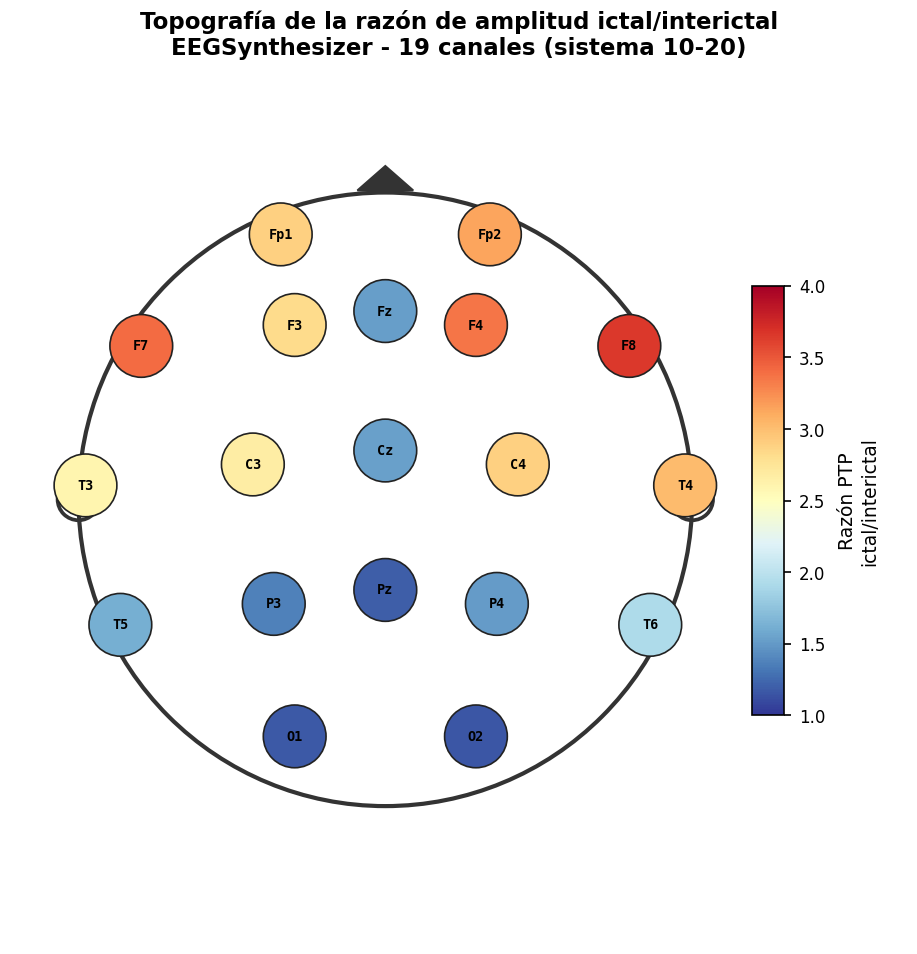

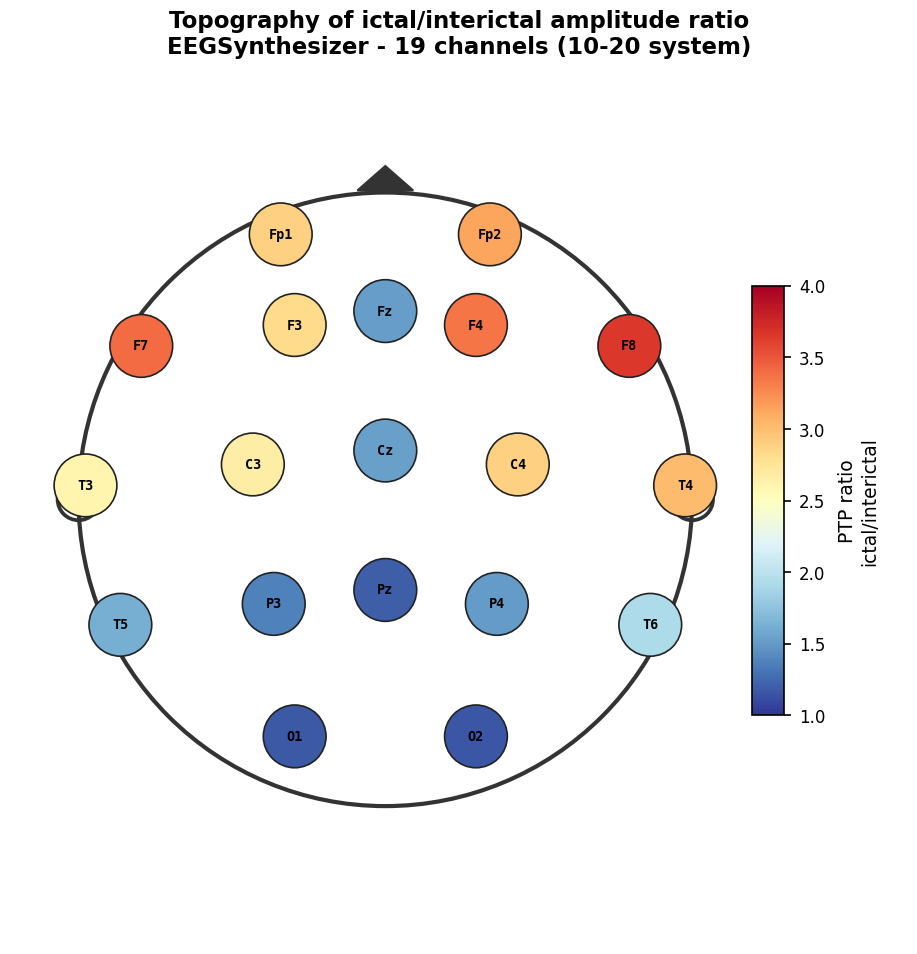

{
  "schema_version": "2.1-symmetry-evaluability-audit-code-hash",
  "generated_utc": "2026-08-11T02:46:20Z",
  "source_generation_manifest_sha256": "08091538c5cb593ea711139db512145ef505b0bbc2dcface273807434a7b2db0",
  "validator_notebook_code_sha256": "2a921f5b891826ac2d1d61ebfdecd5ad22edd5c0cfb0f447feefb3d3e9a94099",
  "validator_notebook_hash_scope": "code_cells_v1",
  "traceability_migration_id": "2026-08-runall-stable-notebook-code-hash-v4",
  "detail_csv": "07_generalized_symmetry_by_patient.csv",
  "detail_csv_sha256": "be884aa43f6b993b57cfd741e1313d4b0cb363e102f5eb63122eb78468376f4f",
  "source_hashes_verified": true,
  "topography_publication": {
    "source_table": {
      "name": "tabla_amplitudes.csv",
      "bytes": 677,
      "sha256": "d43da8fa258ce1ea93639b142d168405116465382e2412a6d461a17c9c6a859b",
      "generation_manifest_entry_sha256": "d43da8fa258ce1ea93639b142d168405116465382e2412a6d461a17c9c6a859b",
      "hash_verified": true
    },
    "files": {
      "fig3_

In [9]:
if GENERATION_MODE=="pilot":
    print("Auditoría post-hoc: NOT EVALUABLE en modo pilot")
    execution_source_check=assert_saved_code_matches_latest_execution(Path.cwd()/"1_0_EEGSynthesizer_DATASET.ipynb")
    print("Código ejecutado/guardado:",execution_source_check)
    _release_eegsynth_pipeline_lock()
else:
    # AUDITORÍA POST-HOC DE SIMETRÍA GENERALIZADA — no recalibra el generador
    import hashlib
    import json
    import time
    from pathlib import Path

    import numpy as np
    import pandas as pd
    from scipy import signal

    AUDIT_ROOT = Path.cwd()
    AUDIT_SYN_DIR = AUDIT_ROOT / "dataset_eeg_final"
    AUDIT_OUT_DIR = AUDIT_ROOT / "dataset_doctorado_final" / "validation_q1_assets"
    AUDIT_DETAIL_PATH = AUDIT_OUT_DIR / "07_generalized_symmetry_by_patient.csv"
    AUDIT_SUMMARY_PATH = AUDIT_OUT_DIR / "07_generalized_symmetry_summary.json"

    AUDIT_FS = 250
    AUDIT_CHANNELS = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
                      'T3','C3','Cz','C4','T4','T5','P3','Pz','P4','T6','O1','O2']
    AUDIT_INDEX = {name: idx for idx, name in enumerate(AUDIT_CHANNELS)}
    AUDIT_PAIRS = [('Fp1','Fp2'), ('F3','F4')]
    AUDIT_PRIMARY = {'Fp1','Fp2','F3','Fz','F4'}
    AUDIT_SYMMETRY_THRESHOLD = 0.35
    AUDIT_ACCEPTANCE_RATE = 0.90

    def audit_sha256(path, block=16*1024*1024):
        digest = hashlib.sha256()
        with Path(path).open("rb") as stream:
            for chunk in iter(lambda: stream.read(block), b""):
                digest.update(chunk)
        return digest.hexdigest()

    def audit_dominant_frequency(x, fs, low=2.0, high=8.0):
        freq, power = signal.welch(np.asarray(x, dtype=np.float64), fs=fs,
                                   nperseg=min(len(x), 2*fs))
        mask = (freq >= low) & (freq <= high)
        return float(freq[mask][np.argmax(power[mask])])

    manifest_path = AUDIT_SYN_DIR / "generation_manifest.json"
    if not manifest_path.is_file():
        raise RuntimeError("Falta generation_manifest.json; la auditoría aborta sin producir artefactos")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    required = ["cohort_metadata.csv","tabla_amplitudes.csv"] + [
        name for split in ("train", "val", "test")
        for name in (f"X_{split}.npy", f"window_metadata_{split}.csv")
    ]
    missing = [name for name in required if not (AUDIT_SYN_DIR/name).exists()]
    if missing:
        raise RuntimeError(f"Faltan entradas de la auditoría: {missing}")

    hash_failures = []
    for name in required:
        recorded = manifest.get("files", {}).get(name, {}).get("sha256")
        observed = audit_sha256(AUDIT_SYN_DIR/name)
        if not recorded or observed != recorded:
            hash_failures.append(name)
    if hash_failures:
        raise RuntimeError(f"SHA256 de entradas inválido: {hash_failures}")

    cohort = pd.read_csv(AUDIT_SYN_DIR/"cohort_metadata.csv")
    context_columns={"scenario","split","start_s","degraded_channels","symmetry_ok",
                     "measurement_clean","duration_s","co_artifact","artifact_fraction",
                     "target_ptp_uv","observed_ptp_uv","target_rel_error","amplitude_ok"}
    if not context_columns.issubset(cohort.columns):
        raise RuntimeError("cohort_metadata.csv no contiene el contexto completo de medición")
    ictal = cohort[cohort.scenario != "none"].copy()
    if len(ictal)!=1500:
        raise RuntimeError(f"Se esperaban 1500 eventos ictales y hay {len(ictal)}")
    amp_cfg=manifest.get("config",{}).get("target_ptp_uv",{})
    amp_min=float(amp_cfg.get("min",150.0)); amp_max=float(amp_cfg.get("max",600.0))
    amp_tol=float(amp_cfg.get("relative_tolerance",0.05))
    amplitude_contract=(ictal.amplitude_ok.astype(bool) &
      ictal.target_ptp_uv.between(amp_min,amp_max,inclusive="both") &
      ictal.observed_ptp_uv.between(amp_min,amp_max,inclusive="both") &
      ictal.target_rel_error.le(amp_tol))
    clean_mask=ictal.measurement_clean.astype(bool); fallback=ictal[~clean_mask].copy()
    central_clean_capacity_s=WIN_SEC/(1.0-2.0*0.20)
    short_fallback=fallback.duration_s.lt(central_clean_capacity_s)
    measurement_context={
      "n_ictal_events":int(len(ictal)),"clean_measurement_count":int(clean_mask.sum()),
      "clean_measurement_rate":float(clean_mask.mean()),"fallback_count":int((~clean_mask).sum()),
      "fallback_rate":float((~clean_mask).mean()),"fallback_short_central_region_count":int(short_fallback.sum()),
      "fallback_no_clean_full_window_count":int((~short_fallback).sum()),
      "fallback_with_co_injected_artifact_count":int(fallback.co_artifact.astype(bool).sum()),
      "fallback_without_co_injected_artifact_count":int((~fallback.co_artifact.astype(bool)).sum()),
      "central_clean_window_duration_threshold_s":float(central_clean_capacity_s),
    }
    generalized = cohort[cohort.scenario == "generalized_absence"].copy()
    if len(generalized) != 750:
        raise RuntimeError(f"Se esperaban 750 eventos generalizados y hay {len(generalized)}")
    if not generalized.symmetry_ok.isin([True,False]).all():
        raise RuntimeError("symmetry_ok histórico contiene valores no booleanos")

    sos = signal.butter(4, [1.0, 30.0], btype="bandpass", fs=AUDIT_FS, output="sos")
    rows = []; processed_events=0
    print("Reevaluando simetría generalizada: 0/750",flush=True)
    for split in ("train", "val", "test"):
        X = np.load(AUDIT_SYN_DIR/f"X_{split}.npy", mmap_mode="r")
        wm = pd.read_csv(AUDIT_SYN_DIR/f"window_metadata_{split}.csv")
        groups = {int(pid): group.sort_values("window_start_s")
                  for pid, group in wm.groupby("patient_id", sort=False)}
        split_events = generalized[generalized.split == split]
        for record in split_events.itertuples(index=False):
            group = groups.get(int(record.patient_id))
            if group is None or len(group) != 60:
                raise RuntimeError(f"Ventanas incompletas para paciente {record.patient_id}")
            starts = group.window_start_s.to_numpy(float)
            if not np.allclose(starts, np.arange(60)*2.0):
                raise RuntimeError(f"Secuencia temporal inválida para paciente {record.patient_id}")
            full = np.concatenate([np.asarray(X[int(idx)])
                                   for idx in group.window_index], axis=0).T
            i0 = int(round(float(record.start_s)*AUDIT_FS))
            i1 = min(full.shape[1], i0 + int(round(float(record.duration_s)*AUDIT_FS)))
            if i1-i0 < 3*12:
                raise RuntimeError(f"Evento demasiado corto para paciente {record.patient_id}")
            event = signal.sosfiltfilt(sos, full[:, i0:i1], axis=1)
            ptp = np.ptp(event, axis=1)
            degraded = (set(str(record.degraded_channels).split("|"))
                        if pd.notna(record.degraded_channels) else set())
            pair_values = {}
            clean_values = []
            for left, right in AUDIT_PAIRS:
                value = float(abs(ptp[AUDIT_INDEX[left]]-ptp[AUDIT_INDEX[right]]) /
                              (max(ptp[AUDIT_INDEX[left]], ptp[AUDIT_INDEX[right]])+1e-12))
                pair_values[f"{left}_{right}"] = value
                if left not in degraded and right not in degraded:
                    clean_values.append(value)
            all_asymmetry = float(np.median(list(pair_values.values())))
            clean_evaluable = bool(clean_values)
            clean_asymmetry = (float(np.median(clean_values)) if clean_evaluable else float("nan"))
            clean_ok = (bool(clean_asymmetry <= AUDIT_SYMMETRY_THRESHOLD) if clean_evaluable else None)
            final_ok = bool(all_asymmetry <= AUDIT_SYMMETRY_THRESHOLD)
            frequency = audit_dominant_frequency(event[AUDIT_INDEX["Fz"]], AUDIT_FS)
            peak_channel = AUDIT_CHANNELS[int(np.argmax(ptp))]
            rows.append({
                "patient_id": int(record.patient_id), "split": split,
                "degraded_channels": "|".join(sorted(degraded)),
                "frontal_pair_degraded": bool(any(ch in degraded for pair in AUDIT_PAIRS for ch in pair)),
                "asymmetry_Fp1_Fp2": pair_values["Fp1_Fp2"],
                "asymmetry_F3_F4": pair_values["F3_F4"],
                "clean_nondegraded_asymmetry": clean_asymmetry,
                "final_all_channels_asymmetry": all_asymmetry,
                "historical_symmetry_ok": bool(record.symmetry_ok),
                "clean_nondegraded_evaluable": clean_evaluable,
                "clean_nondegraded_symmetry_ok": clean_ok,
                "final_all_channels_symmetry_ok": final_ok,
                "dominant_frequency_fz_hz": frequency,
                "frequency_2_5_4_ok": bool(2.5 <= frequency <= 4.0),
                "peak_channel": peak_channel,
                "frontcentral_peak_ok": bool(peak_channel in AUDIT_PRIMARY),
                "measurement_clean": bool(record.measurement_clean),
                "duration_s": float(record.duration_s),
                "co_artifact": bool(record.co_artifact),
                "artifact_fraction": float(record.artifact_fraction),
                "target_ptp_uv": float(record.target_ptp_uv),
                "observed_ptp_uv": float(record.observed_ptp_uv),
                "target_rel_error": float(record.target_rel_error),
            })
            processed_events+=1
            if processed_events%50==0 or processed_events==750: print(f"Reevaluando simetría generalizada: {processed_events}/750",flush=True)

    detail = pd.DataFrame(rows).sort_values("patient_id").reset_index(drop=True)
    if len(detail) != len(generalized) or detail.patient_id.duplicated().any():
        raise RuntimeError("Cobertura de pacientes inválida en auditoría de simetría")
    if not np.isfinite(detail[["asymmetry_Fp1_Fp2", "asymmetry_F3_F4",
                               "final_all_channels_asymmetry",
                               "dominant_frequency_fz_hz"]].to_numpy()).all():
        raise RuntimeError("NaN/Inf en resultados de simetría")

    clean_evaluable_mask=detail.clean_nondegraded_evaluable.astype(bool)
    if not detail.loc[clean_evaluable_mask,"clean_nondegraded_asymmetry"].notna().all():
        raise RuntimeError("Falta asimetría clean_nondegraded en eventos evaluables")
    if not detail.loc[~clean_evaluable_mask,"clean_nondegraded_asymmetry"].isna().all():
        raise RuntimeError("Los eventos no evaluables no deben recibir asimetría clean_nondegraded")
    historical_pass_count=int(detail.historical_symmetry_ok.eq(True).sum())
    clean_evaluable_count=int(clean_evaluable_mask.sum())
    clean_not_evaluable_count=int((~clean_evaluable_mask).sum())
    clean_pass_count=int(detail.loc[clean_evaluable_mask,"clean_nondegraded_symmetry_ok"].eq(True).sum())
    clean_fail_count=clean_evaluable_count-clean_pass_count
    final_pass_count=int(detail.final_all_channels_symmetry_ok.eq(True).sum())
    observed_counts={"historical_pass":historical_pass_count,"clean_evaluable":clean_evaluable_count,
                     "clean_not_evaluable":clean_not_evaluable_count,"clean_pass":clean_pass_count,
                     "clean_fail":clean_fail_count,"final_pass":final_pass_count}
    expected_counts={"historical_pass":750,"clean_evaluable":742,"clean_not_evaluable":8,
                     "clean_pass":742,"clean_fail":0,"final_pass":603}
    if observed_counts!=expected_counts:
        raise RuntimeError(f"Regresión en auditoría de simetría: esperado {expected_counts}, observado {observed_counts}")
    clean_rate = float(clean_pass_count/clean_evaluable_count)
    final_rate = float(final_pass_count/len(detail))
    if not AUDIT_OUT_DIR.is_dir() or not AUDIT_DETAIL_PATH.is_file() or not AUDIT_SUMMARY_PATH.is_file():
        raise RuntimeError("La transacción solo reemplaza los productos 07 existentes; no crea destinos finales")
    published_summary=json.loads(AUDIT_SUMMARY_PATH.read_text(encoding="utf-8"))
    frozen_generated_utc=published_summary.get("generated_utc")
    if not frozen_generated_utc: raise RuntimeError("El producto 07 publicado carece de generated_utc congelado")
    if RUN_AUDIT_ONLY:
        recomputed_detail_csv=detail.to_csv(index=False,lineterminator="\n")
        published_detail_csv=AUDIT_DETAIL_PATH.read_text(encoding="utf-8").replace("\r\n","\n").replace("\r","\n")
        if recomputed_detail_csv!=published_detail_csv: raise RuntimeError("La reevaluación serializada no coincide exactamente con 07_generalized_symmetry_by_patient.csv")
        topography_publication=inspect_and_display_bilingual_topography()
        if topography_publication!=published_summary.get("topography_publication"):
            raise RuntimeError("Las topografías publicadas no coinciden con el producto 07 congelado")
        detail_sha256=audit_sha256(AUDIT_DETAIL_PATH); staged_topography={}; detail_part=None
    else:
        require_authorized_write("productos 07 y topografías")
        topography_publication,staged_topography=stage_bilingual_topography_from_table()
        detail_part=AUDIT_DETAIL_PATH.with_name(AUDIT_DETAIL_PATH.stem+".stage.csv")
        if detail_part.exists():
            for part in staged_topography.values():
                if part.exists(): part.unlink()
            raise RuntimeError(f"Staging residual; revise antes de continuar: {detail_part}")
        try:
            detail.to_csv(detail_part,index=False)
            if not detail_part.is_file() or detail_part.stat().st_size==0: raise RuntimeError("Staging CSV vacío")
        except BaseException:
            for part in list(staged_topography.values())+[detail_part]:
                if part.exists(): part.unlink()
            raise
        detail_sha256=audit_sha256(detail_part)
    summary = {
        "schema_version": "2.1-symmetry-evaluability-audit-code-hash",
        "generated_utc": frozen_generated_utc,
        "source_generation_manifest_sha256": audit_sha256(manifest_path),
        "validator_notebook_code_sha256": notebook_code_sha256(AUDIT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb"),
        "validator_notebook_hash_scope": NOTEBOOK_HASH_SCOPE,
        "traceability_migration_id": TRACEABILITY_MIGRATION_ID,
        "detail_csv": AUDIT_DETAIL_PATH.name,
        "detail_csv_sha256": detail_sha256,
        "source_hashes_verified": True,
        "topography_publication": topography_publication,
        "generator_parameters_changed": False,
        "generator_recalibrated": False,
        "external_cohort_used": False,
        "development_profile_reconciliation": PROVENANCE_RECONCILIATION,
        "amplitude_measurement_context": measurement_context,
        "final_amplitude_contract": {
            "status": "SUPPORTED" if bool(amplitude_contract.all()) else "NOT SUPPORTED",
            "pass_count": int(amplitude_contract.sum()),
            "total_count": int(len(amplitude_contract)),
            "interpretation": "PTP final observado dentro de 150-600 µV y tolerancia relativa predefinida",
        },
        "universal_clean_measurement": {
            "status": "SUPPORTED" if bool(clean_mask.all()) else "NOT SUPPORTED",
            "pass_count": int(clean_mask.sum()),
            "total_count": int(len(clean_mask)),
            "interpretation": "Los eventos fallback conservan amplitud válida, pero impiden afirmar medición limpia universal",
        },
        "n_generalized_events": int(len(detail)),
        "symmetry_relative_difference_threshold": AUDIT_SYMMETRY_THRESHOLD,
        "acceptance_rate": AUDIT_ACCEPTANCE_RATE,
        "historical_indicator": {
            "status": "HISTORICAL",
            "pass_count": historical_pass_count,
            "total_count": int(len(detail)),
            "pass_rate": float(historical_pass_count/len(detail)),
            "field": "cohort_metadata.symmetry_ok",
            "interpretation": "Indicador legado calculado durante generación; se conserva para trazabilidad y no sustituye la reevaluación post-hoc.",
        },
        "clean_nondegraded": {
            "status": "SUPPORTED" if clean_rate >= AUDIT_ACCEPTANCE_RATE else "NOT SUPPORTED",
            "pass_count": clean_pass_count,
            "fail_count": clean_fail_count,
            "evaluable_count": clean_evaluable_count,
            "not_evaluable_count": clean_not_evaluable_count,
            "total_count": int(len(detail)),
            "pass_rate": clean_rate,
            "pass_rate_denominator": "evaluable_count",
            "not_evaluable_reason": "ambos pares frontales predefinidos contienen al menos un canal degradado",
            "interpretation": "742/742 eventos evaluables cumplen; 8/750 son NOT EVALUABLE y no se contabilizan como éxitos.",
        },
        "final_all_channels": {
            "status": "SUPPORTED" if final_rate >= AUDIT_ACCEPTANCE_RATE else "NOT SUPPORTED",
            "pass_count": final_pass_count,
            "fail_count": int(len(detail)-final_pass_count),
            "total_count": int(len(detail)),
            "pass_rate": final_rate,
            "interpretation": "simetría observable después de degradación de adquisición",
        },
        "events_with_frontal_pair_degradation": int(detail.frontal_pair_degraded.sum()),
        "frequency_2_5_4": {
            "pass_count": int(detail.frequency_2_5_4_ok.sum()),
            "pass_rate": float(detail.frequency_2_5_4_ok.mean()),
        },
        "frontcentral_peak": {
            "pass_count": int(detail.frontcentral_peak_ok.sum()),
            "pass_rate": float(detail.frontcentral_peak_ok.mean()),
        },
        "overall_interpretation": (
            "El indicador histórico es 750/750. La reevaluación clean_nondegraded respalda 742/742 "
            "eventos evaluables y marca 8/750 como NOT EVALUABLE; la señal final cumple en 603/750."
        ),
    }
    if RUN_AUDIT_ONLY:
        if summary!=published_summary:
            differing=sorted(key for key in set(summary)|set(published_summary) if summary.get(key)!=published_summary.get(key))
            raise RuntimeError(f"La auditoría en memoria no coincide con 07_generalized_symmetry_summary.json: {differing}")
        if read_only_artifact_snapshot(AUDIT_READ_ONLY_PATHS)!=AUDIT_READ_ONLY_SNAPSHOT:
            raise RuntimeError("audit_only detectó una escritura en datos/productos protegidos")
        execution_source_check=assert_saved_code_matches_latest_execution(AUDIT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb")
        print(json.dumps(summary,indent=2,ensure_ascii=False))
        print("Topografías bilingües verificadas y mostradas en memoria:",topography_publication["files"])
        print("Verificación read-only completada UTC:",time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime()))
        print("Código ejecutado/guardado:",execution_source_check)
    else:
        require_authorized_write("promoción de productos 07")
        summary_part=AUDIT_SUMMARY_PATH.with_name(AUDIT_SUMMARY_PATH.stem+".stage.json")
        if summary_part.exists():
            for part in list(staged_topography.values())+[detail_part]:
                if part.exists(): part.unlink()
            raise RuntimeError(f"Staging residual; revise antes de continuar: {summary_part}")
        try:
            summary_part.write_text(json.dumps(summary,indent=2,ensure_ascii=False)+"\n",encoding="utf-8")
            if not summary_part.is_file() or summary_part.stat().st_size==0: raise RuntimeError("Staging JSON vacío")
            staged_artifacts=dict(staged_topography)
            staged_artifacts[AUDIT_DETAIL_PATH]=detail_part
            staged_artifacts[AUDIT_SUMMARY_PATH]=summary_part
            if len(staged_artifacts)!=4 or not all(Path(path).is_file() for path in staged_artifacts.values()):
                raise RuntimeError("Los cuatro artefactos deben estar staged antes de cualquier reemplazo")
            promote_staged_artifact_set(staged_artifacts)
        except BaseException:
            for part in list(staged_topography.values())+[detail_part,summary_part]:
                if part.exists(): part.unlink()
            raise
        execution_source_check=assert_saved_code_matches_latest_execution(AUDIT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb")
        print(json.dumps(summary,indent=2,ensure_ascii=False))
        print("Topografías bilingües actualizadas desde tabla_amplitudes.csv:",topography_publication["files"])
        print("Código ejecutado/guardado:",execution_source_check)
    _release_eegsynth_pipeline_lock()
